#Proyecto Machine Learning

## Grupo Zeta:

- Wagner Dueñas
- Cindy Cunalata
- Viviana Huachizaca

# Entegabre 1

## Revisión preliminar de los datos:
Identifique el número de características, sus tipos de datos:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_test = pd.read_csv('vehiculos_test.csv')
df_test.head()

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
0,0,Volkswagen,Passat,Blue,2015.0,Saloon,37723.0,2.0L,Automatic,Diesel,12690.0,5.0,4.0,Flat Tyres,0,2018-04-03,1,23.807,1.0,2018-04-03
1,1,Jaguar,XF,White,2014.0,Saloon,78000.0,2.2L,Automatic,Diesel,13490.0,5.0,4.0,Steering Wheel Shaking,0,2018-05-14,3,73.490,3.0,2018-05-14
2,2,Volkswagen,Polo,Orange,2010.0,Hatchback,44936.0,1.4L,Automatic,Petrol,NaN,5.0,5.0,Alternator Failing,0,2018-08-16,1,160.000,2.0,2018-08-16
3,3,Audi,S5,Black,2014.0,Coupe,29000.0,3.0L,Automatic,Petrol,22990.0,4.0,3.0,Steering Wheel Shaking,0,2018-07-24,1,42.990,1.0,2018-07-24
4,4,Toyota,Yaris,Black,2016.0,Hatchback,18037.0,1.33L,Manual,Petrol,9293.0,5.0,5.0,Electrical Issue,2,2018-05-04,1,28.586,0.5,2018-05-04


In [4]:
df_train = pd.read_csv('vehiculos_train.csv')
df_train.head()

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
0,Jeep,Renegade,Black,2018.0,SUV,17.0,1.4L,Manual,Petrol,16000.0,5.0,5.0,Electrical Issue,5,2018-06-07,1,76.0000,3.0,2018-06-07,0
1,Vauxhall,Insignia,Grey,2011.0,Hatchback,93000.0,NaN,Manual,Petrol,3995.0,5.0,5.0,Excessive Emissions,0,2018-08-09,1,23.5955,1.0,2018-08-09,0
2,Mercedes-Benz,GLC Class,White,2019.0,SUV,6879.0,2.0L,Automatic,Diesel,31498.0,5.0,5.0,Windscreen Crack,0,2021-06-17,1,38.8988,1.0,2021-06-17,0
3,Renault,NaN,NaN,2014.0,Hatchback,20669.0,1.2L,Manual,Petrol,6950.0,5.0,5.0,Brake Pads Worn,0,2018-04-23,1,43.4750,2.0,2018-04-23,0
4,Ford,C-Max,NaN,2007.0,MPV,84786.0,1.6L,Manual,Petrol,NaN,5.0,5.0,Tyre Alignment,0,2018-05-20,1,10.2600,0.5,2018-05-20,0


In [5]:
df_test.shape

(21826, 20)

In [6]:
df_train.shape

(196429, 20)

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   marca                   196429 non-null  object 
 1   modelo                  177768 non-null  object 
 2   color                   191581 non-null  object 
 3   anio_registro           191599 non-null  float64
 4   tipo_vehiculo           196429 non-null  object 
 5   millas_recorridas       193664 non-null  float64
 6   tamanio_motor           195482 non-null  object 
 7   transmision             196429 non-null  object 
 8   tipo_combustible        196429 non-null  object 
 9   precio_vehiculo         186867 non-null  float64
 10  num_asientos            196429 non-null  float64
 11  num_puertas             196429 non-null  float64
 12  problema_averia         196429 non-null  object 
 13  id_problema_averia      196429 non-null  int64  
 14  fecha_averia        

In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21826 entries, 0 to 21825
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   21826 non-null  int64  
 1   marca                   21826 non-null  object 
 2   modelo                  19719 non-null  object 
 3   color                   21281 non-null  object 
 4   anio_registro           21298 non-null  float64
 5   tipo_vehiculo           21826 non-null  object 
 6   millas_recorridas       21510 non-null  float64
 7   tamanio_motor           21717 non-null  object 
 8   transmision             21826 non-null  object 
 9   tipo_combustible        21826 non-null  object 
 10  precio_vehiculo         20805 non-null  float64
 11  num_asientos            21826 non-null  float64
 12  num_puertas             21826 non-null  float64
 13  problema_averia         21826 non-null  object 
 14  id_problema_averia      21826 non-null

### Datos atípicos

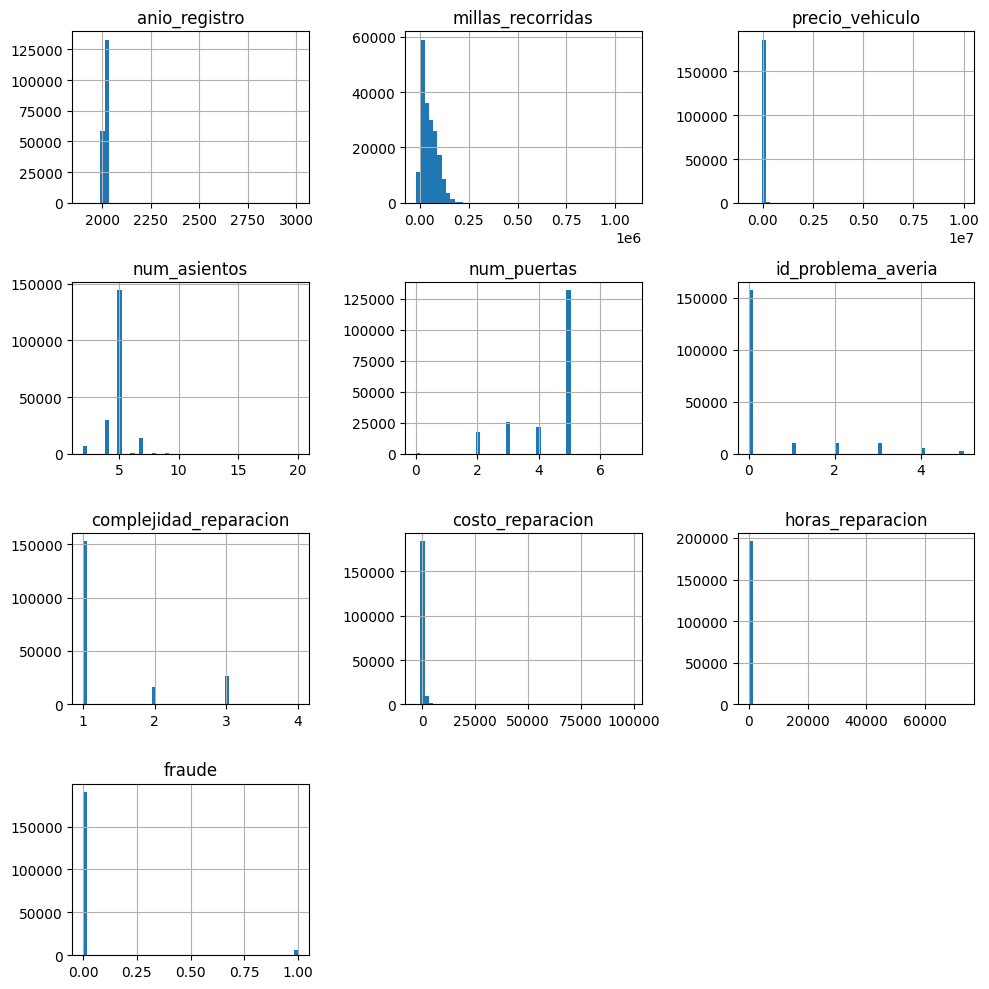

In [9]:
#distribución del dataset train
df_train.hist(bins=50, figsize=(10,10))
plt.tight_layout()
plt.show()

In [10]:
df_train.columns

Index(['marca', 'modelo', 'color', 'anio_registro', 'tipo_vehiculo',
       'millas_recorridas', 'tamanio_motor', 'transmision', 'tipo_combustible',
       'precio_vehiculo', 'num_asientos', 'num_puertas', 'problema_averia',
       'id_problema_averia', 'fecha_averia', 'complejidad_reparacion',
       'costo_reparacion', 'horas_reparacion', 'fecha_reparacion', 'fraude'],
      dtype='object')

In [11]:
df_train.describe()

,anio_registro,millas_recorridas,precio_vehiculo,num_asientos,num_puertas,id_problema_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fraude
count,191599.000000,1.936640e+05,1.868670e+05,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000,196429.000000
mean,2012.678208,4.867635e+04,1.396373e+04,4.935590,4.358593,0.498511,1.366855,342.198345,12.427234,0.030937
std,5.006846,4.004901e+04,3.307734e+04,1.072501,1.031904,1.131135,0.726668,1057.977648,306.762296,0.173149
min,1900.000000,-1.991700e+04,-6.967960e+05,2.000000,0.000000,0.000000,1.000000,-2989.000000,-28.000000,0.000000
25%,2009.000000,1.464700e+04,4.795000e+03,5.000000,4.000000,0.000000,1.000000,35.570000,1.000000,0.000000
50%,2014.000000,4.000000e+04,8.999000e+03,5.000000,5.000000,0.000000,1.000000,105.430000,2.000000,0.000000
75%,2016.000000,7.557125e+04,1.697000e+04,5.000000,5.000000,0.000000,1.000000,288.750000,4.000000,0.000000
max,3010.000000,1.080000e+06,9.999999e+06,20.000000,7.000000,5.000000,4.000000,98690.116330,73134.610091,1.000000


In [12]:
df_test.describe()

,index,anio_registro,millas_recorridas,precio_vehiculo,num_asientos,num_puertas,id_problema_averia,complejidad_reparacion,costo_reparacion,horas_reparacion
count,21826.000000,21298.000000,2.151000e+04,20805.000000,21826.000000,21826.000000,21826.000000,21826.000000,21826.000000,21826.000000
mean,10912.500000,2012.642173,4.920080e+04,13881.703581,4.939705,4.358151,0.497984,1.364336,333.964098,15.289430
std,6300.767824,4.474466,5.913809e+04,20416.159168,1.070112,1.029582,1.132998,0.723578,1027.515853,540.858322
min,0.000000,1990.000000,-1.979300e+04,-612718.000000,1.000000,0.000000,0.000000,1.000000,-2939.000000,-30.000000
25%,5456.250000,2009.000000,1.447875e+04,4700.000000,5.000000,4.000000,0.000000,1.000000,34.395500,1.000000
50%,10912.500000,2014.000000,4.005400e+04,8995.000000,5.000000,5.000000,0.000000,1.000000,100.960000,2.000000
75%,16368.750000,2016.000000,7.600000e+04,16900.000000,5.000000,5.000000,0.000000,1.000000,289.000000,4.000000
max,21825.000000,2019.000000,6.363342e+06,499995.000000,20.000000,6.000000,5.000000,4.000000,65204.822767,71851.662095


In [13]:
#generamos un dataset train nuevo para guardar los nuevos datos luego de la limpieza
df_train_n = df_train.copy()

In [14]:
#generamos un dataset test nuevo para guardar los nuevos datos luego de la limpieza
df_test_n = df_test.copy()

A continuacion, realizaremos limpieza de datos en las variables donde se ha visualizado una distribución erronea.

#### anio_registro

##### df_train

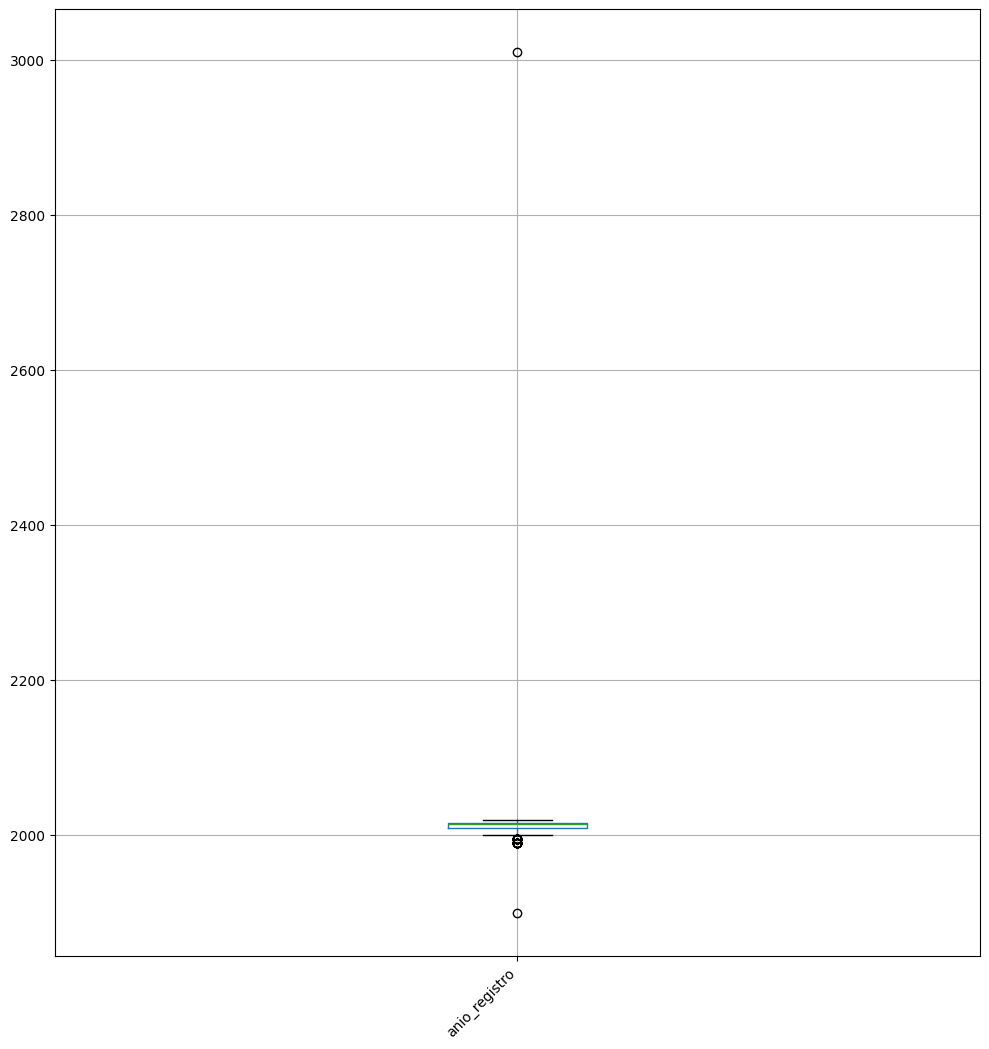

In [15]:
#visualización de valores atípicos del dataset train
df_train[['anio_registro']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [16]:
#visualización de valores atípicos del dataset train
df_train[['anio_registro']].groupby('anio_registro').size()

anio_registro
1900.0        1
1990.0       12
1995.0       19
2000.0      496
2001.0     1163
2002.0     1962
2003.0     2449
2004.0     3797
2005.0     4346
2006.0     6919
2007.0     8032
2008.0     9449
2009.0     9267
2010.0    10735
2011.0    10953
2012.0    12147
2013.0    12914
2014.0    15766
2015.0    20862
2016.0    15951
2017.0    19104
2018.0    12591
2019.0    12663
3010.0        1
dtype: int64

In [17]:
#analizamos las caracteristica que tiene el carro con el anio aberrante
df_train[df_train['anio_registro']==1900.0]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
23716,Vauxhall,Corsa,Grey,1900.0,Hatchback,NaN,1.4L,Manual,Petrol,8500.0,12.0,0.0,Gear Box Issue,0,2018-05-04,1,626.373971,475.223492,2018-06-01,1


In [18]:
#filtramos el df con las mismas caracteristicas que tiene el carro con el anio aberrante
df_train[(df_train['marca']=='Vauxhall') & (df_train['modelo']=='Corsa') & (df_train['tamanio_motor']=='1.4L') & (df_train['precio_vehiculo']==8500.0)& (df_train['color']=='Grey')]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
23716,Vauxhall,Corsa,Grey,1900.0,Hatchback,NaN,1.4L,Manual,Petrol,8500.0,12.0,0.0,Gear Box Issue,0,2018-05-04,1,626.373971,475.223492,2018-06-01,1
75841,Vauxhall,Corsa,Grey,2016.0,Hatchback,10945.0,1.4L,Manual,Petrol,8500.0,5.0,5.0,Transmission Issue,1,2018-04-20,1,105.500000,4.000000,2018-04-21,0


In [19]:
#reemplazamos el anio de otro carro similar que tiene caracteristicas similares
df_train_n.loc[df_train_n['anio_registro'] == 1900.0, 'anio_registro'] = 2016.0


In [20]:
#analizamos las caracteristica que tiene el carro con el anio aberrante
df_train[df_train['anio_registro']==3010.0]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
166214,BMW,7 Series,Grey,3010.0,Wood,-2038.0,999.0L,Hybrid,Hydrogen,-182067.0,12.0,0.0,Excessive Emissions,0,2018-04-15,1,-418.0,1.0,2018-04-15,1


In [21]:
#filtramos el df con las mismas caracteristicas que tiene el carro con el anio aberrante
# df_train[(df_train['marca']=='BMW') & (df_train['modelo']=='7 Series') & (df_train['tamanio_motor']=='999.0L')& (df_train['color']=='Grey')].head(23)
df_train[(df_train['marca']=='BMW') & (df_train['modelo']=='7 Series') & (df_train['color']=='Grey')].groupby('anio_registro').size().sort_values()

anio_registro
3010.0    1
2003.0    2
2006.0    2
2005.0    2
2008.0    3
2010.0    3
2015.0    3
2007.0    3
2012.0    3
2013.0    4
2011.0    4
2009.0    6
2017.0    6
2014.0    6
2018.0    8
2016.0    8
2019.0    9
dtype: int64

In [22]:
#reemplazamos el anio de otro carro similar que tiene caracteristicas similares
df_train_n.loc[df_train_n['anio_registro'] == 3010.0, 'anio_registro'] = 2019.0

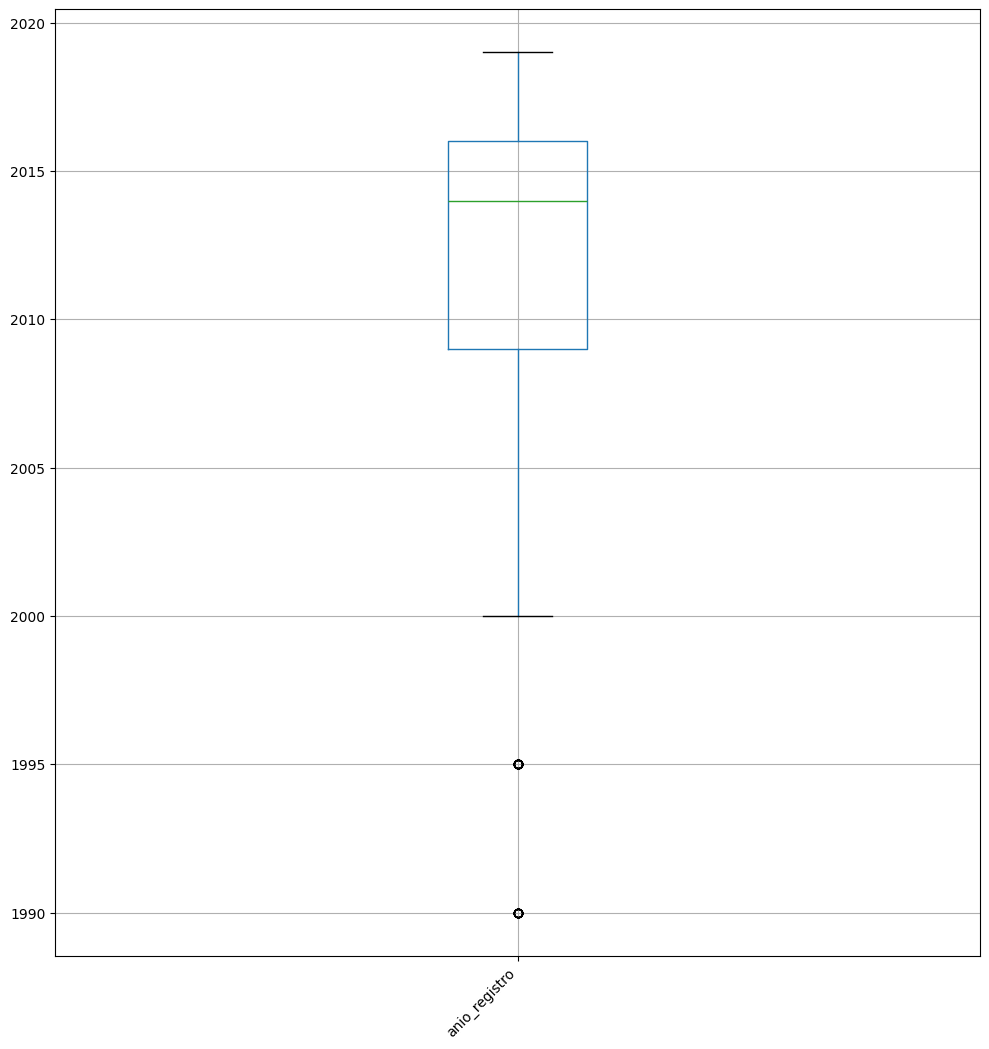

In [23]:
#visualización de valores atípicos del dataset limpio
df_train_n[['anio_registro']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

##### df_test

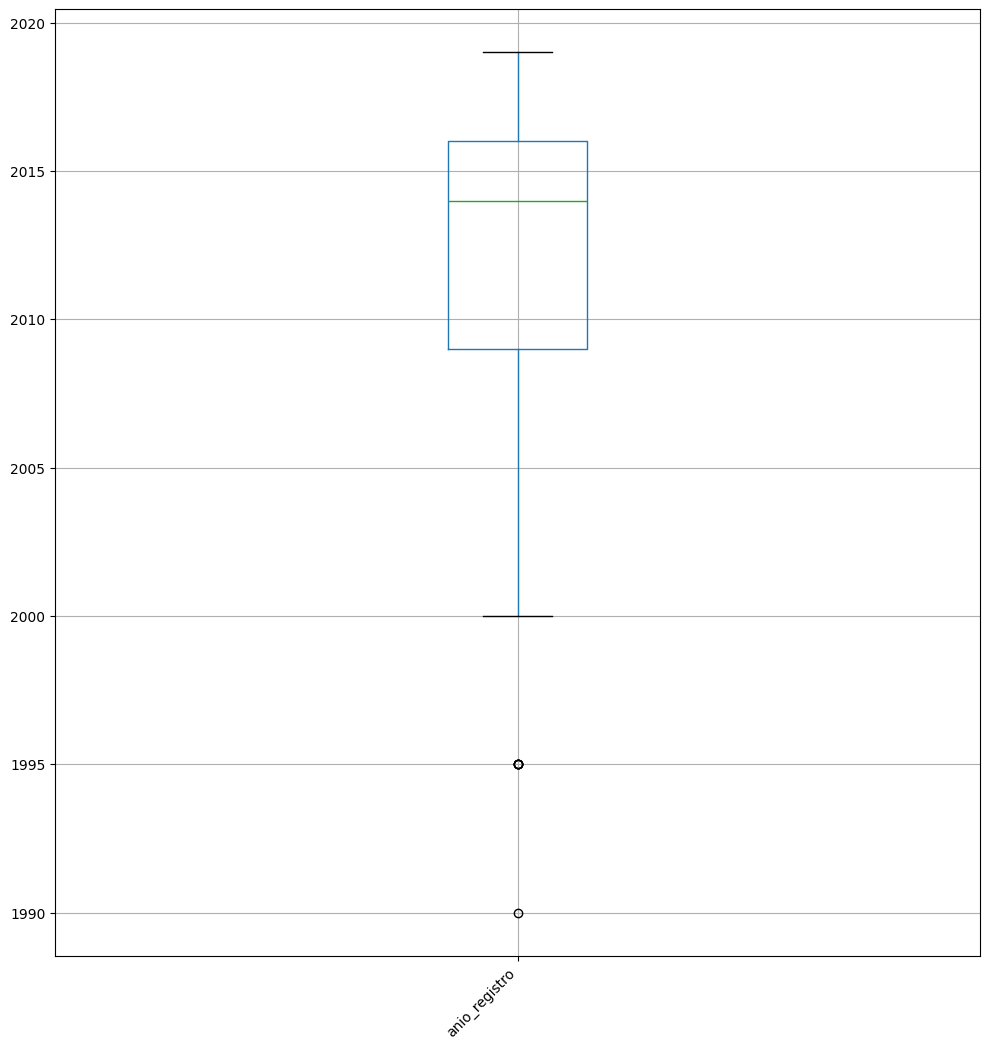

In [24]:
#visualización de valores atípicos del dataset test. No se visualizan datos aberrantes
df_test[['anio_registro']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

####millas_recorridas

#####df_train

In [25]:
df_train['millas_recorridas'].describe()

count    1.936640e+05
mean     4.867635e+04
std      4.004901e+04
min     -1.991700e+04
25%      1.464700e+04
50%      4.000000e+04
75%      7.557125e+04
max      1.080000e+06
Name: millas_recorridas, dtype: float64

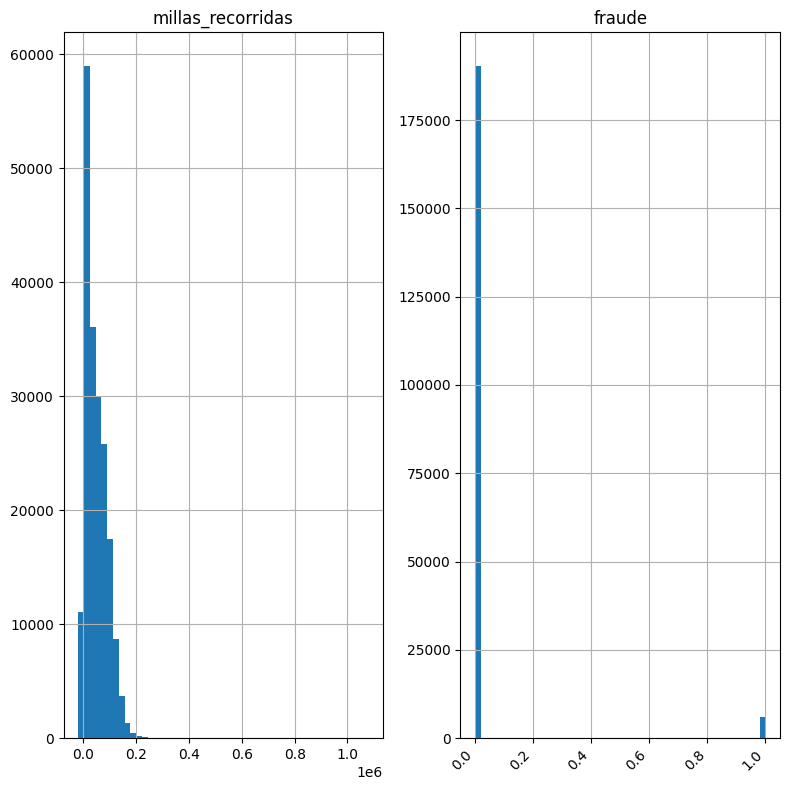

In [26]:
df_train[['millas_recorridas','fraude']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

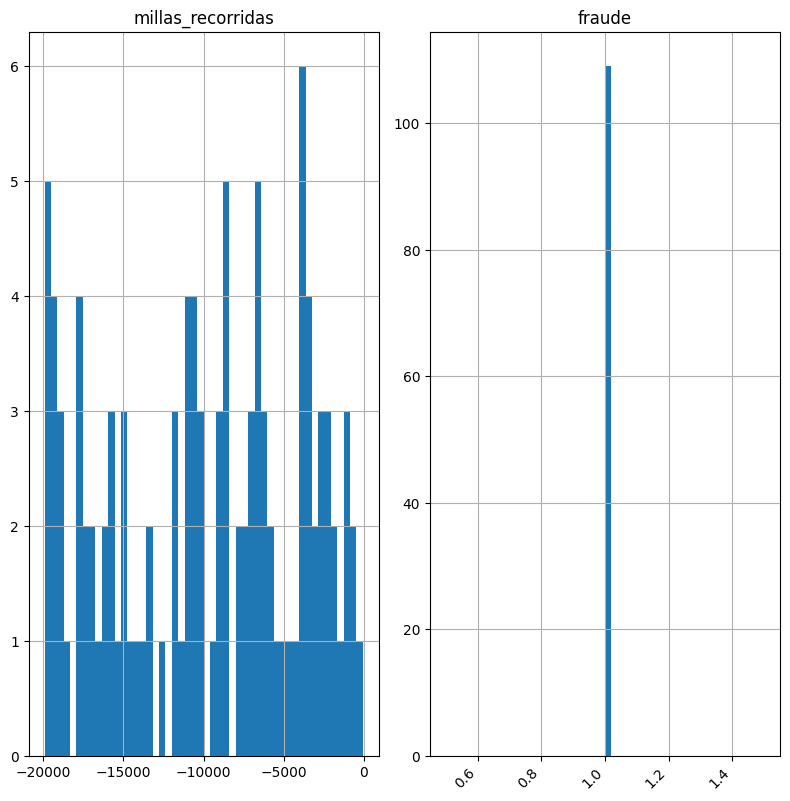

In [27]:
df_train.loc[df_train['millas_recorridas']<0,['millas_recorridas','fraude']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [28]:
df_test['millas_recorridas'].describe()

count    2.151000e+04
mean     4.920080e+04
std      5.913809e+04
min     -1.979300e+04
25%      1.447875e+04
50%      4.005400e+04
75%      7.600000e+04
max      6.363342e+06
Name: millas_recorridas, dtype: float64

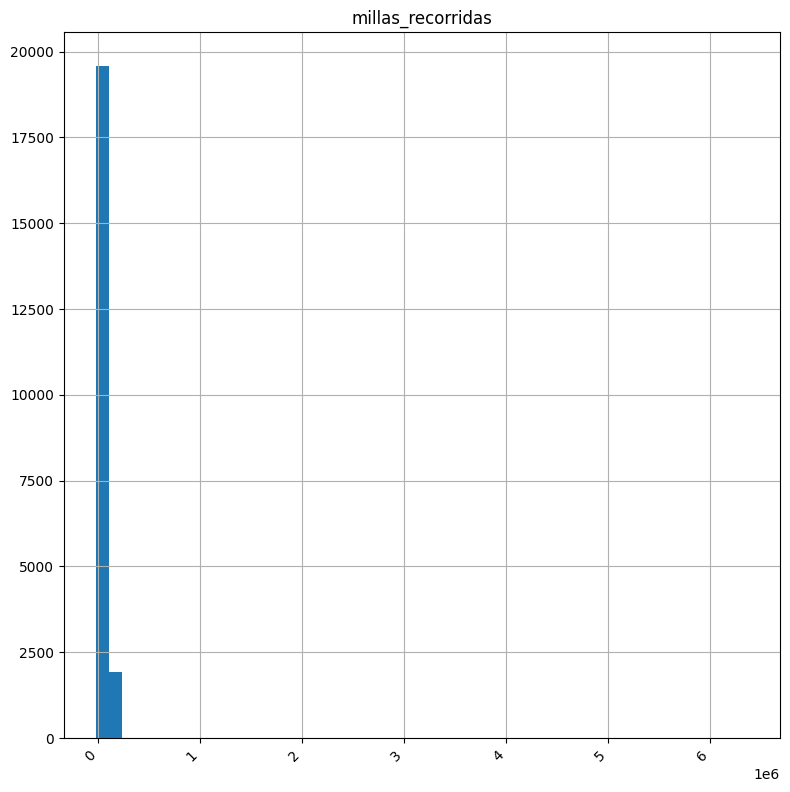

In [29]:
df_test[['millas_recorridas']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

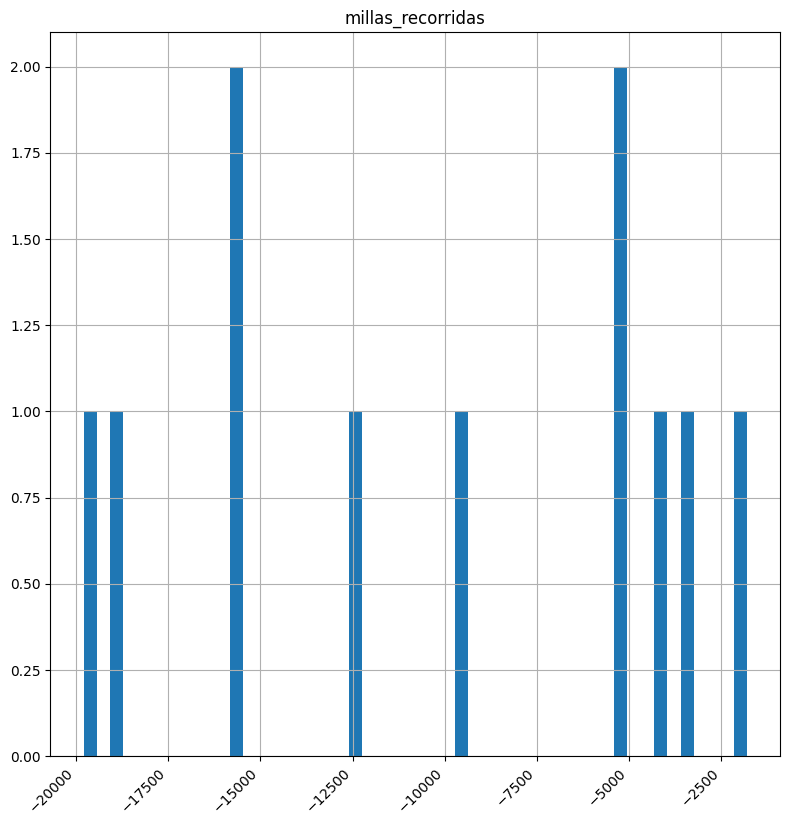

In [30]:
df_test.loc[df_test['millas_recorridas']<0,['millas_recorridas']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

Hasta ahora hemos visto que casi la totalidad de los casos de fraude están en los vehiculos con millaje negativo, por lo que eliminar dichos valores no es una opción. Todo parece indicar un error de tipeo a la hora de registrar estos valores, por lo que procederemos a realizar dicha correccion.

In [31]:
df_train_n['millas_recorridas'] = df_train_n['millas_recorridas'].abs()

In [32]:
df_train_n['millas_recorridas'].describe()

count    1.936640e+05
mean     4.868746e+04
std      4.003550e+04
min      0.000000e+00
25%      1.465575e+04
50%      4.000000e+04
75%      7.557125e+04
max      1.080000e+06
Name: millas_recorridas, dtype: float64

#####df_test

In [33]:
df_test_n['millas_recorridas'] = df_test_n['millas_recorridas'].abs()

In [34]:
df_test_n['millas_recorridas'].describe()

count    2.151000e+04
mean     4.921120e+04
std      5.912943e+04
min      0.000000e+00
25%      1.449375e+04
50%      4.005400e+04
75%      7.600000e+04
max      6.363342e+06
Name: millas_recorridas, dtype: float64

####precio_vehiculo


#####df_train

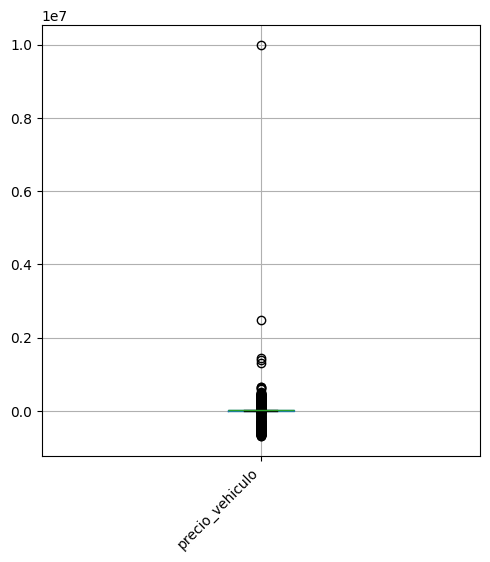

In [35]:
df_train[['precio_vehiculo']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [36]:
#comparar los precio de un vehiculo en valores positivos con vehiculos que tienen precio negativo.
df_train[(df_train['marca']=='BMW') & (df_train['modelo']=='6 Series Gran Turismo') & (df_train['tipo_vehiculo']=='Hatchback')]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
1099,BMW,6 Series Gran Turismo,Black,NaN,Hatchback,4299.0,3.0L,Automatic,Diesel,37992.0,5.0,5.0,Starter Motor Issue,0,2018-07-24,1,439.9200,3.0,2018-07-24,0
1685,BMW,6 Series Gran Turismo,Blue,2017.0,Hatchback,4158.0,3.0L,Automatic,Diesel,37951.0,5.0,5.0,Windscreen Crack,0,2018-08-05,1,42.7706,1.0,2018-08-05,0
2903,BMW,6 Series Gran Turismo,White,2017.0,Hatchback,5650.0,3.0L,Automatic,Diesel,-33329.0,5.0,5.0,Electrical Issue,5,2018-03-20,1,-700.0000,3.0,2018-03-20,1
5720,BMW,6 Series Gran Turismo,Grey,2017.0,Hatchback,5651.0,3.0L,Automatic,Diesel,-34768.0,5.0,5.0,Starter Motor Issue,0,2018-02-20,1,-1696.0000,3.0,2018-02-20,1
9068,BMW,6 Series Gran Turismo,Black,2017.0,Hatchback,4028.0,3.0L,Automatic,Diesel,-17402.0,5.0,5.0,Engine Issue,2,2017-11-27,1,-2784.0000,16.0,2017-12-01,1
11302,BMW,6 Series Gran Turismo,Grey,2019.0,Hatchback,20614.0,3.0L,Automatic,Diesel,31995.0,5.0,5.0,Windscreen Crack,0,2021-03-18,1,39.1970,1.0,2021-03-18,0
28455,BMW,6 Series Gran Turismo,Black,2019.0,Hatchback,16945.0,3.0L,Automatic,Diesel,28290.0,5.0,5.0,Steering Wheel Shaking,0,2021-04-13,1,48.2900,1.0,2021-04-13,0
29523,BMW,6 Series Gran Turismo,Grey,2019.0,Hatchback,13070.0,2.0L,Automatic,Petrol,28775.0,5.0,5.0,Tyre Alignment,0,2021-06-01,1,12.8775,0.5,2021-06-01,0
35182,BMW,6 Series Gran Turismo,White,2017.0,Hatchback,1944.0,3.0L,Automatic,Diesel,-572209.0,5.0,5.0,Brake Pads Worn,0,2017-12-23,1,-297.0000,2.0,2017-12-23,1
46589,BMW,6 Series Gran Turismo,Black,2017.0,Hatchback,10.0,3.0L,Automatic,Diesel,-565756.0,5.0,5.0,Windscreen Crack,0,2017-12-25,1,-2728.0000,1.0,2017-12-25,1


In [37]:
# Remplazar valores negativos en 'precio de vehiculo' por sui valor absoluto.
df_train_n['precio_vehiculo'] = df_train_n['precio_vehiculo'].abs()

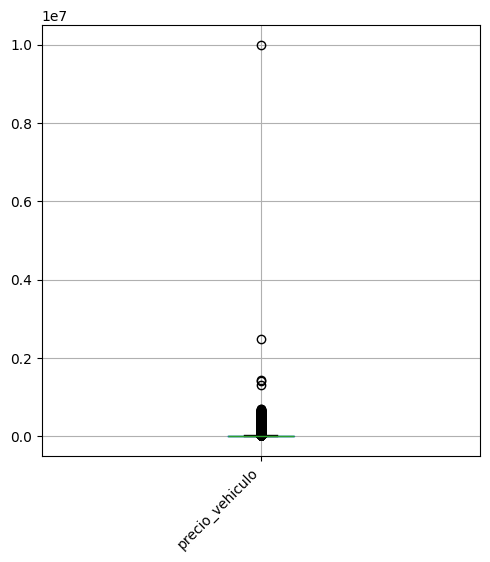

In [38]:
#Comprobamos que ya no existen valores negativos en 'precio-vehiculo'
df_train_n[['precio_vehiculo']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [39]:
#ante la existencia de un valor atipico, verificamos su indice
df_train_n[df_train_n['precio_vehiculo']==df_train_n['precio_vehiculo'].max()]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
177859,McLaren,675LT,Silver,2016.0,Coupe,200.0,3.8L,Automatic,Petrol,9999999.0,2.0,2.0,Transmission Issue,1,2017-06-09,3,30239.997,12.0,2017-06-12,0


In [40]:
#Verificamos cual fue el precio del vehiculo segun caracteristicas del vehiculo
df_train[(df_train['marca']=='McLaren') & (df_train['modelo']=='675LT') & (df_train['tipo_vehiculo']=='Coupe') & (df_train['tamanio_motor']=='3.8L')]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
84210,McLaren,675LT,Grey,2015.0,Coupe,2484.0,3.8L,Automatic,Petrol,NaN,2.0,2.0,Sensor Malfunction,0,2018-05-03,3,13327.5000,9.0,2018-05-05,0
121757,McLaren,675LT,Orange,2016.0,Coupe,2850.0,3.8L,Automatic,Petrol,259850.0,2.0,2.0,Brake Pads Worn,0,2018-01-19,3,249.9250,6.0,2018-01-20,0
125176,McLaren,675LT,Orange,2016.0,Coupe,662.0,3.8L,Automatic,Petrol,244950.0,2.0,2.0,Engine Issue,1,2017-10-21,3,49470.0000,24.0,2017-10-27,0
155036,McLaren,675LT,White,2015.0,Coupe,30000.0,3.8L,Automatic,Petrol,269989.0,2.0,2.0,Flat Tyres,0,2017-04-24,3,140.9967,3.0,2017-04-24,0
164787,McLaren,675LT,Green,2016.0,Coupe,786.0,3.8L,Automatic,Petrol,279990.0,2.0,2.0,Steering Wheel Shaking,0,2018-03-06,3,339.9900,3.0,2018-03-06,0
172193,McLaren,675LT,Purple,2015.0,Coupe,800.0,3.8L,Automatic,Petrol,299900.0,2.0,2.0,Electrical Issue,1,2018-03-22,3,419.9000,6.0,2018-03-23,0
177859,McLaren,675LT,Silver,2016.0,Coupe,200.0,3.8L,Automatic,Petrol,9999999.0,2.0,2.0,Transmission Issue,1,2017-06-09,3,30239.9970,12.0,2017-06-12,0


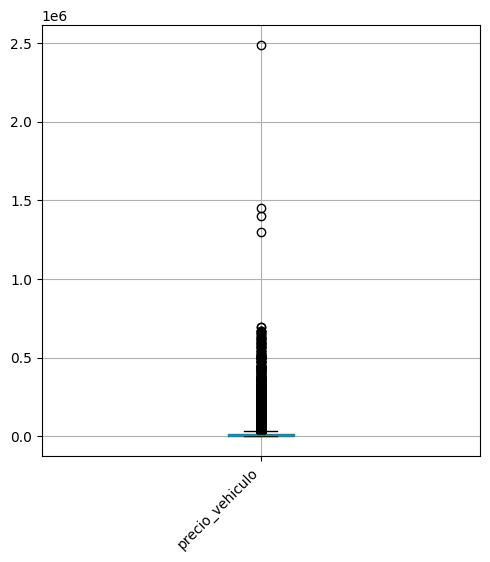

In [41]:
# Calculamos la media de'precio_vehiculo' para los indices que tienen las mismas caracteristicas que el vehiculo con precio atipico y reemplazamos.
indices_to_average = [84210, 121757, 125176, 155036, 164787, 172193]
mean_precio = df_train.loc[indices_to_average, 'precio_vehiculo'].mean()
mean_precio

# Remplazamos por la media
df_train_n.loc[177859, 'precio_vehiculo'] = mean_precio

#Comprobamos que ya no existen valores negativos en 'precio-vehiculo'
df_train_n[['precio_vehiculo']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#####df_test

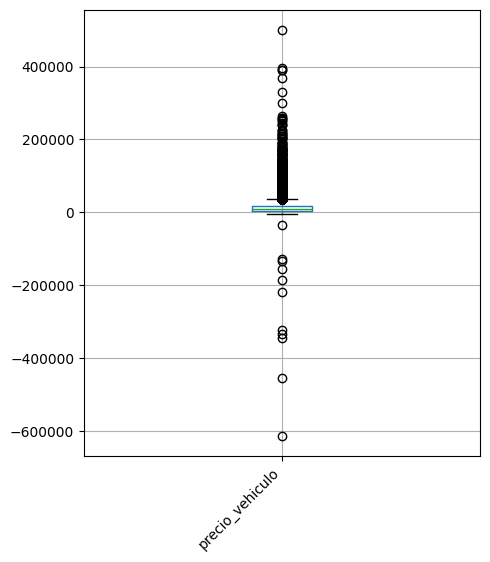

In [42]:
df_test[['precio_vehiculo']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
#comparar los precio de un vehiculo en valores positivos con vehiculos que tienen precio negativo.
df_test[(df_test['marca']=='BMW') & (df_test['modelo']=='6 Series Gran Turismo') & (df_test['tipo_vehiculo']=='Hatchback')]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
874,874,BMW,6 Series Gran Turismo,Blue,2019.0,Hatchback,10645.0,3.0L,Automatic,Diesel,30300.0,5.0,5.0,Windscreen Crack,0,2021-04-28,1,38.180,1.0,2021-04-28
6477,6477,BMW,6 Series Gran Turismo,Grey,2017.0,Hatchback,1969.0,3.0L,Automatic,Diesel,41450.0,5.0,5.0,Excessive Emissions,0,2018-07-07,1,57.305,1.0,2018-07-07
6482,6482,BMW,6 Series Gran Turismo,Grey,2017.0,Hatchback,8878.0,3.0L,Automatic,Diesel,34980.0,5.0,5.0,Brake Pads Worn,0,2018-08-12,1,57.490,2.0,2018-08-12
9417,9417,BMW,6 Series Gran Turismo,Grey,2017.0,Hatchback,110.0,3.0L,Automatic,Diesel,-35867.0,5.0,5.0,Engine Issue,4,2017-12-26,1,-1857.000,10.0,2017-12-28
19903,19903,BMW,6 Series Gran Turismo,Black,2019.0,Hatchback,2050.0,3.0L,Automatic,Diesel,33450.0,5.0,5.0,Flat Tyres,0,2021-04-28,1,30.035,1.0,2021-04-28


In [44]:
#comparar los precio de un vehiculo en valores positivos con vehiculos que tienen precio negativo.
df_test[(df_test['marca']=='BMW') & (df_test['modelo']=='7 Series') & (df_test['tipo_vehiculo']=='Saloon')]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
999,999,BMW,7 Series,Black,NaN,Saloon,3850.0,6.6L,Automatic,Petrol,-218479.0,4.0,4.0,Sensor Malfunction,0,2018-01-27,1,-1414.000000,3.000000,2018-01-27
1045,1045,BMW,7 Series,Black,2019.0,Saloon,3541.0,3.0L,Automatic,Diesel,48000.0,5.0,4.0,Excessive Emissions,0,2021-04-18,1,63.200000,1.000000,2021-04-18
1114,1114,BMW,7 Series,Grey,2015.0,Saloon,11000.0,3.0L,Automatic,Petrol,23480.0,5.0,4.0,Radiator Leaking,0,2018-06-22,1,509.600000,2.000000,2018-06-22
1192,1192,BMW,7 Series,Grey,2016.0,Saloon,9850.0,3.0L,Automatic,Diesel,67295.0,5.0,4.0,Electrical Issue,1,2017-05-18,1,-2172.000000,2.000000,2017-05-18
1259,1259,BMW,7 Series,Silver,2009.0,Saloon,73000.0,3.0L,Automatic,Diesel,12940.0,5.0,4.0,Excessive Emissions,0,2018-08-13,1,31.646000,1.000000,2018-08-13
1303,1303,BMW,7 Series,Black,2019.0,Saloon,10000.0,3.0L,Automatic,Diesel,47990.0,5.0,4.0,Tyre Alignment,0,2021-05-21,1,14.799000,0.500000,2021-05-21
2111,2111,BMW,7 Series,Black,2019.0,Saloon,5000.0,3.0L,Automatic,Petrol Plug-in Hybrid,46000.0,5.0,4.0,Electrical Issue,5,2021-04-21,1,106.000000,3.000000,2021-04-21
2711,2711,BMW,7 Series,Black,2013.0,Saloon,76000.0,3.0L,Automatic,Petrol,19990.0,5.0,4.0,Windscreen Crack,0,2018-08-13,1,31.994000,1.000000,2018-08-13
3307,3307,BMW,7 Series,Black,2013.0,Saloon,46800.0,3.0L,Automatic,Diesel,16995.0,5.0,4.0,Flat Tyres,0,2018-08-09,1,25.098500,1.000000,2018-08-09
3365,3365,BMW,7 Series,Silver,2012.0,Saloon,116500.0,3.0L,Automatic,Diesel,12490.0,5.0,4.0,Electrical Issue,5,2018-06-05,1,72.490000,3.000000,2018-06-05


In [45]:
df_test_n['precio_vehiculo'] = df_test_n['precio_vehiculo'].abs()

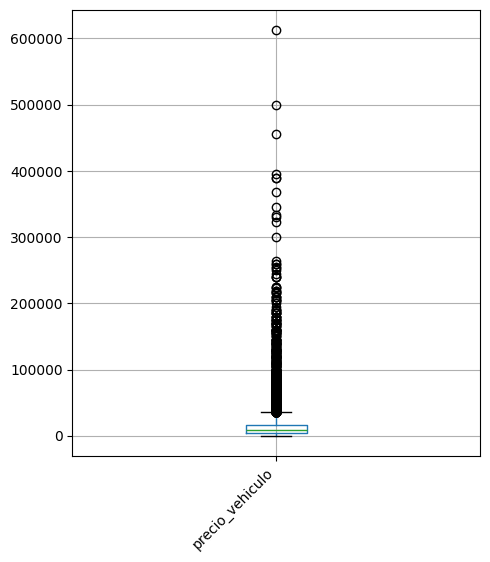

In [46]:
df_test_n[['precio_vehiculo']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [47]:
df_test_n[df_test_n['precio_vehiculo'] < 0]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion


####num_puertas

#####df_train

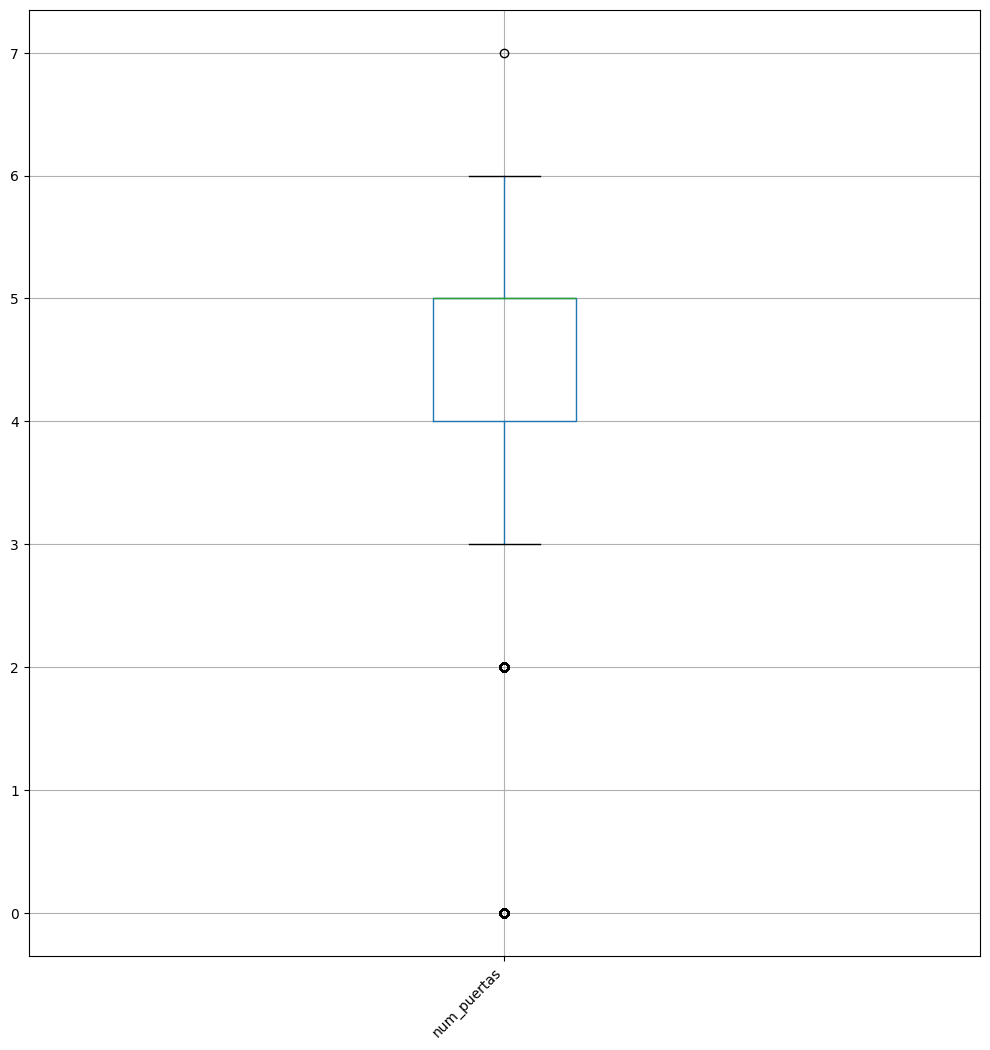

In [48]:
df_train[['num_puertas']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [49]:
#solo tenemos un vehiculo con esta cantidad de puertas. Se ha investigado el modelo y se ha encontrado que tiene 5 puertas en lugar de 7
df_train[df_train['num_puertas']== 7]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
47558,Ford,Grand Tourneo Connect,Red,2015.0,MPV,31000.0,1.6L,Automatic,Petrol,13500.0,7.0,7.0,Transmission Issue,1,2018-08-27,1,120.5,4.0,2018-08-28,0


In [50]:
#reemplazamos el anio de otro carro similar que tiene caracteristicas similares
df_train_n.loc[df_train_n['num_puertas'] == 7, 'num_puertas'] = 5

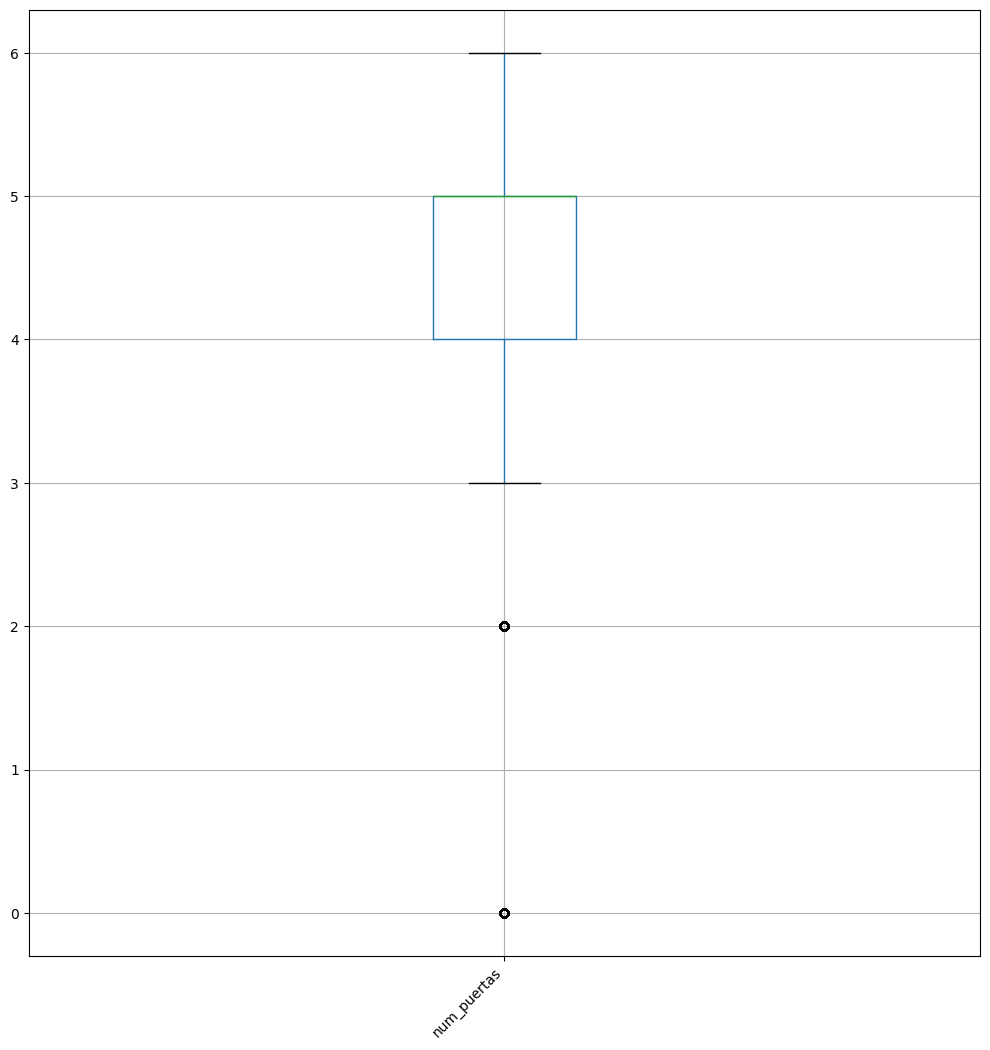

In [51]:
#visualización de valores atípicos del dataset limpio
df_train_n[['num_puertas']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#####df_test

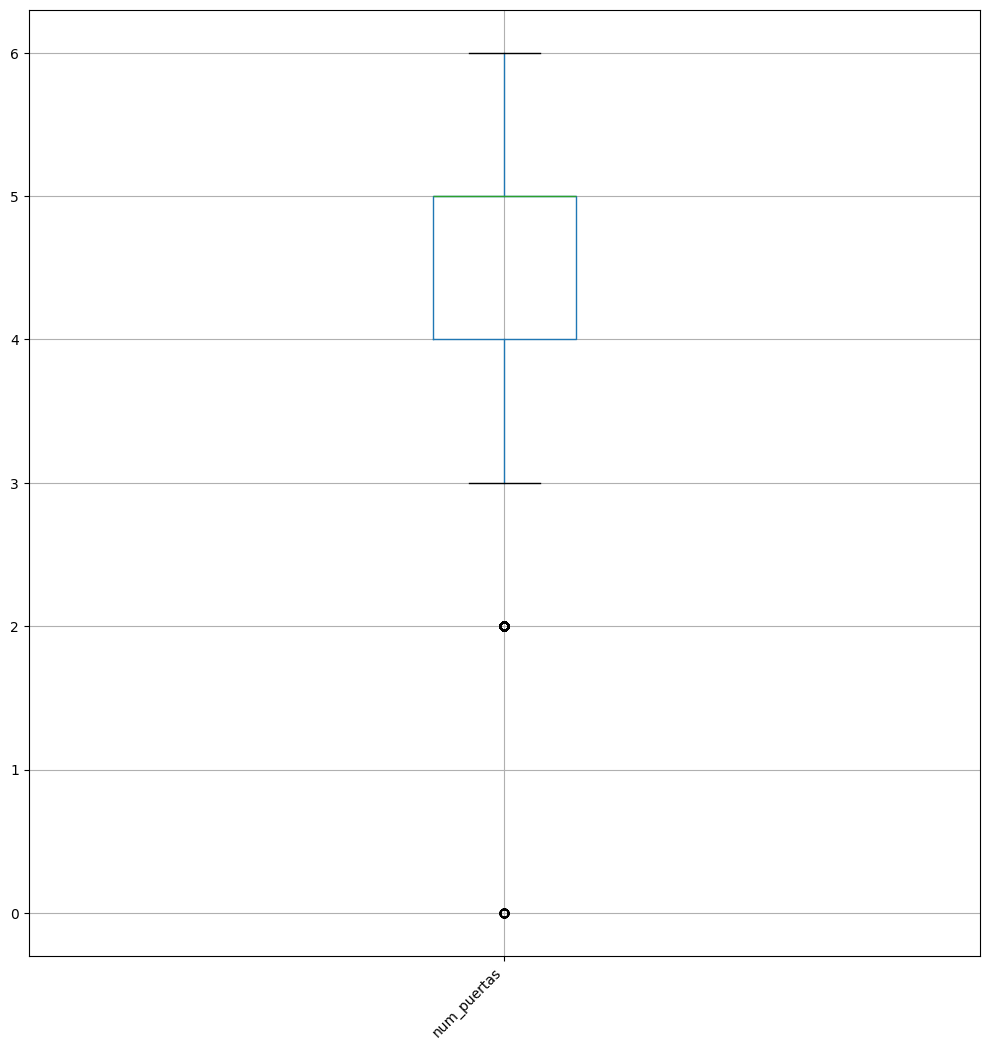

In [52]:
#No se visualizan datos aberrantes
df_test[['num_puertas']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#### costo_reparacion

#####df_train

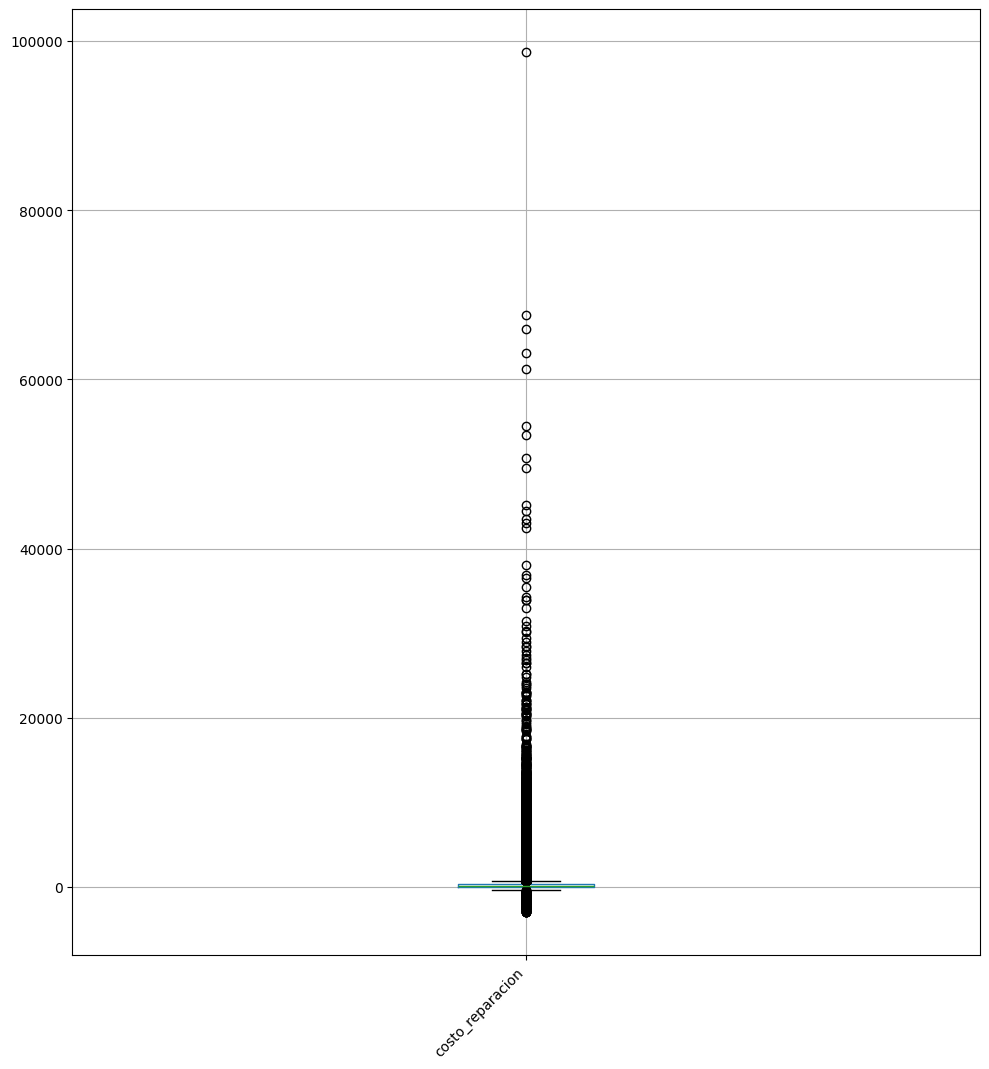

In [53]:
#visualización de valores atípicos del dataset train
#df_co = df_train[['costo_reparacion']]
#df_co[df_train['costo_reparacion'] < 0].boxplot(figsize=(10, 10))
df_train[['costo_reparacion']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [54]:
#datos que tienen ruido, no deberían estar con valor negativo
df_train[df_train['costo_reparacion'] < 0].groupby(['marca','problema_averia']).size()

marca  problema_averia       
BMW    Alternator Failing         9
       Brake Pads Worn           10
       Electrical Issue          12
       Engine Issue               6
       Excessive Emissions       11
       Flat Tyres                 7
       Gear Box Issue             7
       Radiator Leaking           9
       Sensor Malfunction        10
       Starter Motor Issue       10
       Steering Wheel Shaking    10
       Transmission Issue         9
       Tyre Alignment            10
       Warning Light             12
       Windscreen Crack          10
dtype: int64

In [55]:
#analizamos los valores de marcas y modelos similares para ver si fue un error de tipeo
#Los valores se encuentran similares, por lo que si podria ser un error de tipeo
df_train[(df_train['marca']== 'BMW') & (df_train['problema_averia']== 'Engine Issue')&(df_train['modelo'] =='6 Series Gran Coupe')]


,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
13281,BMW,6 Series Gran Coupe,Black,2015.0,Coupe,29999.0,3.0L,Automatic,Petrol,21400.0,5.0,4.0,Engine Issue,4,2018-08-03,1,1270.00,10.0,2018-08-05,0
19146,BMW,6 Series Gran Coupe,White,2015.0,Coupe,36404.0,3.0L,Automatic,Diesel,27286.0,5.0,4.0,Engine Issue,1,2018-08-19,1,5617.20,8.0,2018-08-21,0
37265,BMW,6 Series Gran Coupe,Blue,2018.0,Coupe,121.0,3.0L,Automatic,Diesel,37499.0,5.0,4.0,Engine Issue,2,2018-04-18,1,5944.85,16.0,2018-04-22,0
71269,BMW,6 Series Gran Coupe,Silver,2017.0,Coupe,5805.0,3.0L,Automatic,Diesel,-320245.0,5.0,4.0,Engine Issue,4,2018-01-21,1,-717.00,10.0,2018-01-23,1
128424,BMW,6 Series Gran Coupe,Blue,2016.0,Coupe,25650.0,3.0L,Automatic,Diesel,NaN,5.0,4.0,Engine Issue,1,2018-07-18,1,4500.00,8.0,2018-07-20,0
160591,BMW,6 Series Gran Coupe,Grey,2013.0,Coupe,24000.0,3.0L,Automatic,Diesel,-621486.0,5.0,4.0,Engine Issue,3,2018-03-22,1,-1229.00,12.0,2018-03-25,1
164636,BMW,6 Series Gran Coupe,Blue,2018.0,Coupe,101.0,3.0L,Automatic,Petrol,39000.0,5.0,4.0,Engine Issue,3,2018-07-05,1,4140.00,12.0,2018-07-08,0
173703,BMW,6 Series Gran Coupe,Grey,NaN,Coupe,101.0,3.0L,Automatic,Diesel,42995.0,5.0,4.0,Engine Issue,1,2018-08-20,1,8759.00,8.0,2018-08-22,0
175040,BMW,6 Series Gran Coupe,Black,2016.0,Coupe,11987.0,3.0L,Automatic,Diesel,31592.0,5.0,4.0,Engine Issue,4,2018-07-03,1,1779.60,10.0,2018-07-05,0
188194,BMW,6 Series Gran Coupe,Black,2016.0,Coupe,14502.0,3.0L,Automatic,Diesel,26999.0,5.0,4.0,Engine Issue,2,2018-08-06,1,4369.85,16.0,2018-08-10,0


In [56]:
#reemplazamos los valores por su valor absoluto.
df_train_n['costo_reparacion'] = df_train_n['costo_reparacion'].abs()

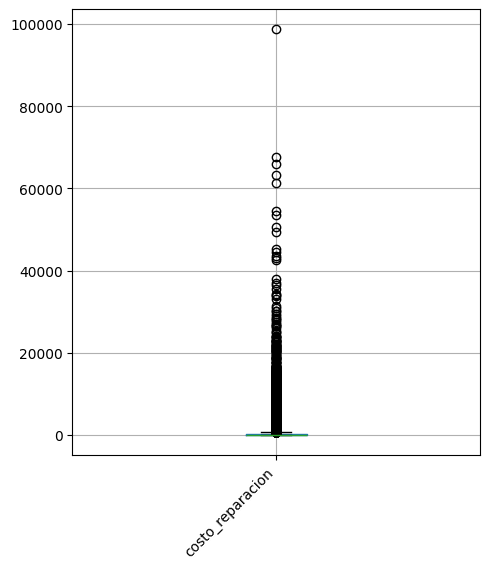

In [57]:
#Comprobamos que ya no existen valores negativos en 'costo_reparacion'
df_train_n[['costo_reparacion']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#####df_test

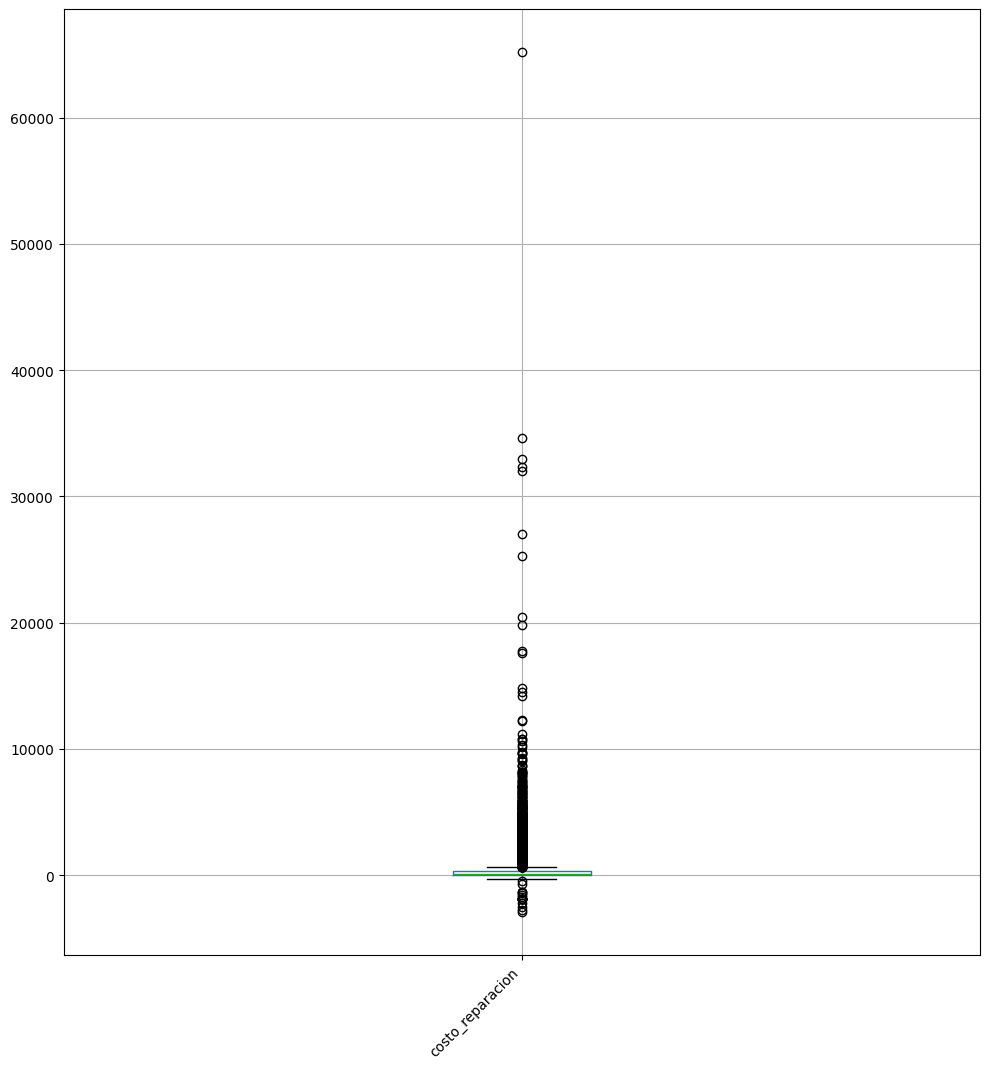

In [58]:
df_test[['costo_reparacion']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [59]:
#datos que tienen ruido, no deberían estar con valor negativo
df_test[df_test['costo_reparacion'] < 0].groupby(['marca','problema_averia']).size()

marca  problema_averia    
BMW    Alternator Failing     1
       Brake Pads Worn        3
       Electrical Issue       4
       Engine Issue           1
       Excessive Emissions    1
       Radiator Leaking       1
       Sensor Malfunction     2
       Starter Motor Issue    1
       Transmission Issue     2
       Tyre Alignment         2
dtype: int64

In [60]:
#analizamos los valores de marcas y modelos similares para ver si fue un error de tipeo
#Los valores de costo reparacion en negativo estan elevados, pero puede deberse a fraude. Por lo que se considera sacar el abs de la variable
df_test[(df_test['marca']== 'BMW') & (df_test['problema_averia']== 'Electrical Issue')]


,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
270,270,BMW,Z4M,Red,2006.0,Convertible,69000.0,3.2L,Manual,Petrol,NaN,2.0,2.0,Electrical Issue,2,2015-05-08,1,39.000000,0.5,2015-05-08
920,920,BMW,X1,Black,2019.0,SUV,19332.0,2.0L,Automatic,Diesel,NaN,5.0,5.0,Electrical Issue,4,2021-05-28,1,103.600000,2.0,2021-05-28
1040,1040,BMW,2 Series Active Tourer,Black,2015.0,MPV,74000.0,1.5L,Manual,Petrol,9990.0,5.0,5.0,Electrical Issue,4,2017-12-05,1,69.970000,2.0,2017-12-05
1192,1192,BMW,7 Series,Grey,2016.0,Saloon,9850.0,3.0L,Automatic,Diesel,67295.0,5.0,4.0,Electrical Issue,1,2017-05-18,1,-2172.000000,2.0,2017-05-18
1217,1217,BMW,X5,White,2017.0,SUV,8882.0,3.0L,Automatic,Diesel,42982.0,5.0,5.0,Electrical Issue,4,2018-08-05,1,168.946000,2.0,2018-08-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20803,20803,BMW,3 Series,Silver,2008.0,Saloon,99000.0,2.0L,Manual,Petrol,2450.0,5.0,4.0,Electrical Issue,4,2018-07-25,1,47.350000,2.0,2018-07-25
20880,20880,BMW,X5,Blue,2004.0,SUV,99000.0,3.0L,Automatic,Diesel,5290.0,5.0,5.0,Electrical Issue,4,2018-06-13,1,55.870000,2.0,2018-06-13
21073,21073,BMW,X1,Black,2014.0,SUV,110000.0,2.0L,Manual,Diesel,9290.0,5.0,5.0,Electrical Issue,3,2018-08-08,1,221.663662,1.0,2018-08-08
21326,21326,BMW,X6,Black,2019.0,SUV,19000.0,3.0L,Automatic,Diesel,42995.0,5.0,5.0,Electrical Issue,1,2021-06-07,1,82.995000,2.0,2021-06-07


In [61]:
#reemplazamos los valores por su valor absoluto.
df_test_n['costo_reparacion'] = df_test_n['costo_reparacion'].abs()

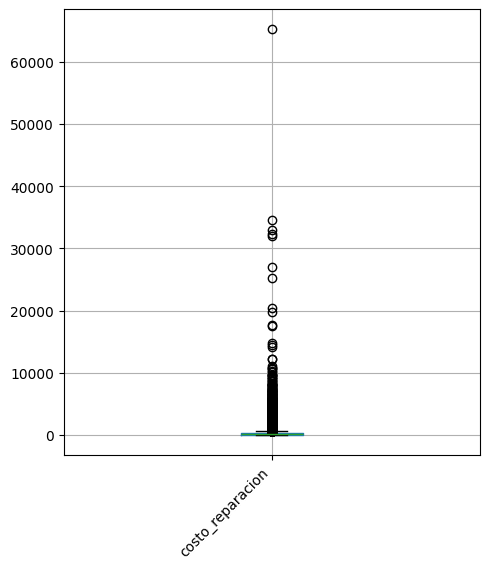

In [62]:
#Comprobamos que ya no existen valores negativos
df_test_n[['costo_reparacion']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

####horas_reparacion

#####df_train

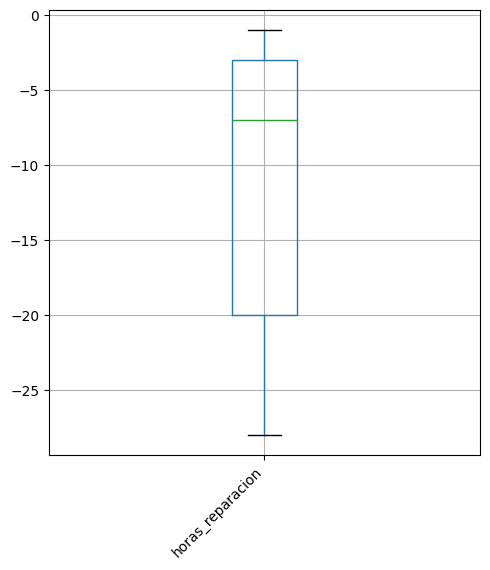

In [63]:
#horas en negativo
df_h = df_train[['horas_reparacion']]
df_h[df_h['horas_reparacion'] < 0].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

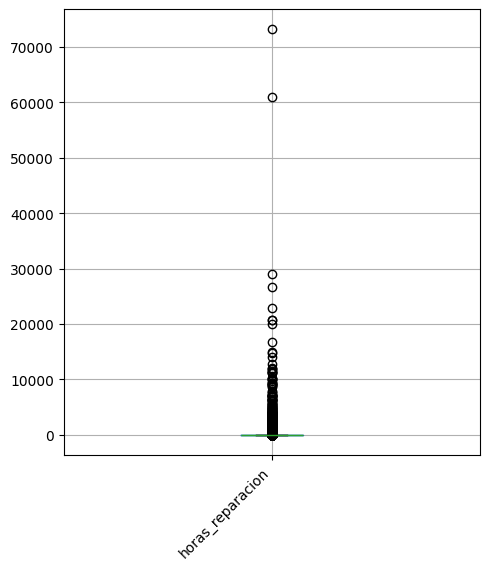

In [64]:
#horas en positivo
df_h[df_h['horas_reparacion'] > 0].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [65]:
df_train[df_train['horas_reparacion'] < 0]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
71254,BMW,7 Series,Grey,2017.0,Saloon,20910.0,3.0L,Automatic,Diesel,-310635.0,5.0,4.0,Sensor Malfunction,0,2018-02-24,1,-313.0,-1.0,2018-02-24,1
85913,BMW,6 Series Gran Coupe,NaN,2015.0,Coupe,19740.0,3.0L,Automatic,Diesel,-655675.0,5.0,4.0,Excessive Emissions,0,2017-09-15,1,-1148.0,-7.0,2017-09-14,1
89727,BMW,M2,Blue,2017.0,Coupe,2600.0,3.0L,Automatic,Petrol,-505104.0,4.0,2.0,Flat Tyres,0,2017-03-08,1,-926.0,-14.0,2017-03-05,1
93827,BMW,M2,White,2017.0,Coupe,4376.0,3.0L,Manual,Petrol,-461602.0,4.0,2.0,Radiator Leaking,0,2018-02-12,1,-1290.0,-3.0,2018-02-12,1
96480,BMW,7 Series,Black,2017.0,Saloon,14271.0,3.0L,Automatic,Diesel,NaN,5.0,4.0,Warning Light,0,2017-12-15,1,-599.0,-3.0,2017-12-15,1
120187,BMW,6 Series Gran Coupe,Black,2014.0,Coupe,48172.0,3.0L,Automatic,Diesel,28490.0,5.0,4.0,Flat Tyres,0,2018-03-15,1,-165.0,-26.0,2018-03-09,1
136280,BMW,6 Series,Silver,2005.0,Coupe,130000.0,3.0L,Automatic,Petrol,-516229.0,4.0,2.0,Alternator Failing,0,2017-11-23,1,-1207.0,-28.0,2017-11-16,1


In [66]:
#analizamos los valores de marcas y caracteristicas similares para ver si fue un error de tipeo
#Los valores se encuentran dentro de un rango similar, por lo que si podria ser un error de tipeo
df_train[(df_train['marca']== 'BMW') & (df_train['problema_averia']== 'Sensor Malfunction')&(df_train['modelo'] =='7 Series')]


,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
9115,BMW,7 Series,Black,2017.0,Saloon,7994.0,3.0L,Automatic,Diesel,43950.0,5.0,4.0,Sensor Malfunction,0,2018-08-23,1,2257.50,3.0,2018-08-23,0
32393,BMW,7 Series,Grey,2016.0,Saloon,27000.0,3.0L,Automatic,Diesel,36995.0,5.0,4.0,Sensor Malfunction,0,2018-07-22,1,1909.75,3.0,2018-07-22,0
34365,BMW,7 Series,White,2016.0,Saloon,18773.0,3.0L,Automatic,Diesel,-308476.0,5.0,4.0,Sensor Malfunction,0,2017-09-13,1,-1298.00,3.0,2017-09-13,1
38030,BMW,7 Series,Silver,2015.0,Saloon,67000.0,3.0L,Automatic,Diesel,16995.0,5.0,4.0,Sensor Malfunction,0,2018-08-14,1,909.75,3.0,2018-08-14,0
38883,BMW,7 Series,Black,NaN,Saloon,140000.0,3.0L,Automatic,Diesel,7800.0,5.0,4.0,Sensor Malfunction,0,2018-08-09,1,450.00,3.0,2018-08-09,0
39315,BMW,7 Series,Grey,2013.0,Saloon,60000.0,6.0L,Automatic,Petrol,-23820.0,5.0,4.0,Sensor Malfunction,0,2018-03-11,1,-968.00,3.0,2018-03-11,1
45776,BMW,7 Series,Blue,2010.0,Saloon,126000.0,3.0L,Automatic,Diesel,8995.0,5.0,4.0,Sensor Malfunction,0,2018-08-04,1,509.75,3.0,2018-08-04,0
55755,BMW,7 Series,Silver,2018.0,Saloon,2981.0,3.0L,Automatic,Diesel,54920.0,5.0,4.0,Sensor Malfunction,0,2018-05-23,1,2806.00,3.0,2018-05-23,0
57292,BMW,7 Series,Black,2018.0,Saloon,5960.0,3.0L,Automatic,Diesel,47280.0,5.0,4.0,Sensor Malfunction,0,2018-05-23,1,2424.00,3.0,2018-05-23,0
70833,BMW,7 Series,Grey,2016.0,Saloon,13510.0,3.0L,Automatic,Diesel,37898.0,5.0,4.0,Sensor Malfunction,0,2018-04-06,1,1954.90,3.0,2018-04-06,0


In [67]:
# Remplazamos valores negativos en horas_reparacion por su valor absoluto.
df_train_n['horas_reparacion'] = df_train_n['horas_reparacion'].abs()

In [68]:
#ante la existencia de un valor atipico, verificamos su indice
#73134.610091 horas ≈ 8 años, 124 días, 4 horas y 26 minutos. No tiene sentido que lleve tantos años en reparación
#por lo que si pudo ser un error de tipeo
df_train_n[df_train_n['horas_reparacion']==df_train_n['horas_reparacion'].max()]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
98111,Bentley,NaN,White,2019.0,Convertible,3899.0,6.0L,Automatic,Petrol,184895.0,4.0,2.0,Engine Issue,3,2021-06-25,3,98690.11633,73134.610091,2021-07-08,1


In [69]:
#analizamos los valores de marcas y caracteristicas similares para ver con que valor podriamos reemplazar
df_train_n[(df_train_n['marca']== 'Bentley') & (df_train_n['problema_averia']== 'Engine Issue')& (df_train_n['tamanio_motor']== '6.0L') & (df_train_n['tipo_vehiculo']== 'Convertible') & (df_train_n['transmision']== 'Automatic') & (df_train_n['complejidad_reparacion']== 3) & (df_train_n['tipo_combustible']== 'Petrol')]


,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
62214,Bentley,Continental,Red,NaN,Convertible,27252.0,6.0L,Automatic,Petrol,105950.0,4.0,2.0,Engine Issue,1,2018-06-10,3,21670.00000,24.000000,2018-06-16,0
63872,Bentley,NaN,Grey,2010.0,Convertible,26000.0,6.0L,Automatic,Petrol,NaN,4.0,2.0,Engine Issue,1,2018-05-24,3,12479.00000,24.000000,2018-05-30,0
84884,Bentley,Continental,Silver,2010.0,Convertible,24900.0,6.0L,Automatic,Petrol,79950.0,4.0,2.0,Engine Issue,2,2017-06-07,3,12952.50000,48.000000,2017-06-19,0
93267,Bentley,Continental,Purple,2014.0,Convertible,30182.0,6.0L,Automatic,Petrol,89950.0,4.0,2.0,Engine Issue,2,2018-08-27,3,14452.50000,48.000000,2018-09-08,0
98111,Bentley,NaN,White,2019.0,Convertible,3899.0,6.0L,Automatic,Petrol,184895.0,4.0,2.0,Engine Issue,3,2021-06-25,3,98690.11633,73134.610091,2021-07-08,1
112424,Bentley,Continental,White,2012.0,Convertible,41267.0,6.0L,Automatic,Petrol,72000.0,4.0,2.0,Engine Issue,4,2018-04-06,3,4200.00000,30.000000,2018-04-13,0
140516,Bentley,Continental,Blue,2008.0,Convertible,42000.0,6.0L,Automatic,Petrol,49995.0,4.0,2.0,Engine Issue,4,2018-04-24,3,3099.75000,30.000000,2018-05-01,0
150684,Bentley,Continental,Grey,2012.0,Convertible,20000.0,6.0L,Automatic,Petrol,74990.0,4.0,2.0,Engine Issue,1,2017-07-06,3,15478.00000,24.000000,2017-07-12,0
166118,Bentley,Continental,White,2012.0,Convertible,39000.0,6.0L,Automatic,Petrol,74900.0,4.0,2.0,Engine Issue,2,2018-07-27,3,12195.00000,48.000000,2018-08-08,0
182404,Bentley,Continental,Black,2011.0,Convertible,20000.0,6.0L,Automatic,Petrol,72950.0,4.0,2.0,Engine Issue,1,2018-03-21,3,15070.00000,24.000000,2018-03-27,0


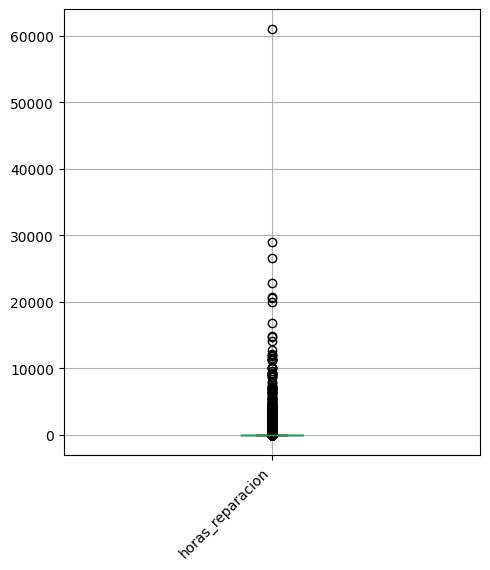

In [70]:
# Calculamos la media para los indices que tienen las mismas caracteristicas que el vehiculo con precio atipico y reemplazamos.
indices_to_average = [62214, 63872, 84884, 93267, 98111, 112424,140516,150684,166118,182404,190652]
mean_hora = df_train_n.loc[indices_to_average, 'horas_reparacion'].mean()
mean_hora

# Remplazamos por la media
df_train_n.loc[98111, 'horas_reparacion'] = mean_hora

#Comprobamos que ya no existen valores negativos
df_train_n[['horas_reparacion']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [71]:
#ante la existencia de OTRO valor atipico, verificamos su indice
#760,997.357327 horas ≈ 6 años, 350 días, 9 horas y 36 minutos. No tiene sentido que lleve tantos años en reparación
#por lo que si pudo ser un error de tipeo
df_train_n[df_train_n['horas_reparacion']==df_train_n['horas_reparacion'].max()]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
89498,Porsche,911,Black,2014.0,Convertible,26056.0,3.8L,Automatic,Petrol,78915.0,4.0,2.0,Engine Issue,1,2018-03-05,3,65961.435406,60997.357327,2018-03-14,1


In [72]:
#analizamos los valores de marcas y caracteristicas similares para ver con que valor podriamos reemplazar
df_train_n[(df_train_n['marca']== 'Porsche') & (df_train_n['problema_averia']== 'Engine Issue')& (df_train_n['tamanio_motor']== '3.8L') & (df_train_n['tipo_vehiculo']== 'Convertible') & (df_train_n['transmision']== 'Automatic') & (df_train_n['complejidad_reparacion']== 3) & (df_train_n['tipo_combustible']== 'Petrol')]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
83468,Porsche,911,Black,2014.0,Convertible,23475.0,3.8L,Automatic,Petrol,79995.0,4.0,2.0,Engine Issue,4,2018-03-21,3,4599.750000,30.000000,2018-03-28,0
89498,Porsche,911,Black,2014.0,Convertible,26056.0,3.8L,Automatic,Petrol,78915.0,4.0,2.0,Engine Issue,1,2018-03-05,3,65961.435406,60997.357327,2018-03-14,1
89721,Porsche,NaN,Grey,2012.0,Convertible,37336.0,3.8L,Automatic,Petrol,61700.0,4.0,2.0,Engine Issue,4,2018-06-10,3,3685.000000,30.000000,2018-06-17,0
108711,Porsche,911,White,2017.0,Convertible,2676.0,3.8L,Automatic,Petrol,153890.0,4.0,2.0,Engine Issue,2,2018-08-25,3,24043.500000,48.000000,2018-09-06,0
122081,Porsche,911,Gelb,2009.0,Convertible,39000.0,3.8L,Automatic,Petrol,41989.0,4.0,2.0,Engine Issue,4,2018-04-09,3,2699.450000,30.000000,2018-04-16,1
148950,Porsche,911,Blue,2007.0,Convertible,28000.0,3.8L,Automatic,Petrol,36490.0,4.0,2.0,Engine Issue,2,2018-06-04,3,6433.500000,48.000000,2018-06-16,0
170192,Porsche,911,Black,2008.0,Convertible,37000.0,3.8L,Automatic,Petrol,47500.0,4.0,2.0,Engine Issue,2,2018-05-10,3,8085.000000,48.000000,2018-05-22,0


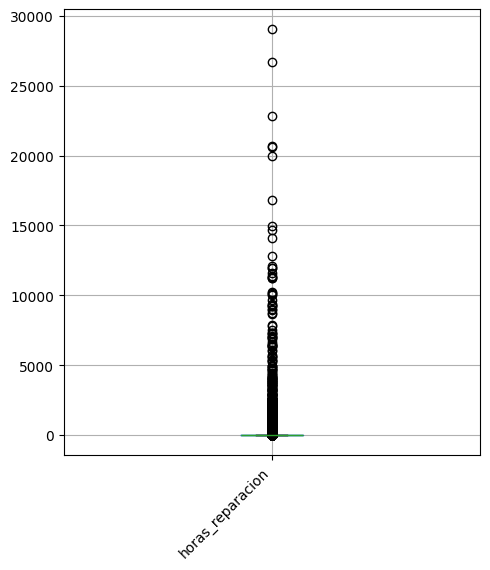

In [73]:
# Calculamos la media para los indices que tienen las mismas caracteristicas que el vehiculo con precio atipico y reemplazamos.
indices_to_average = [83468, 89721, 108711, 122081, 148950,170192]
mean_hora = df_train_n.loc[indices_to_average, 'horas_reparacion'].mean()
mean_hora

# Remplazamos por la media
df_train_n.loc[89498, 'horas_reparacion'] = mean_hora

#Comprobamos que ya no existen valores negativos
df_train_n[['horas_reparacion']].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

#####df_test

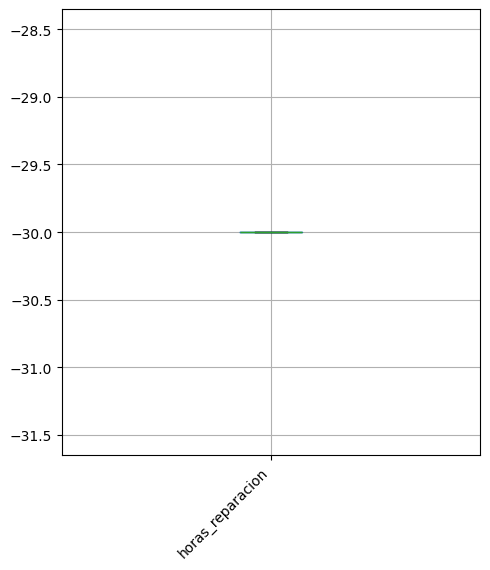

In [74]:
#horas en negativo
df_h = df_test[['horas_reparacion']]
df_h[df_h['horas_reparacion'] < 0].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

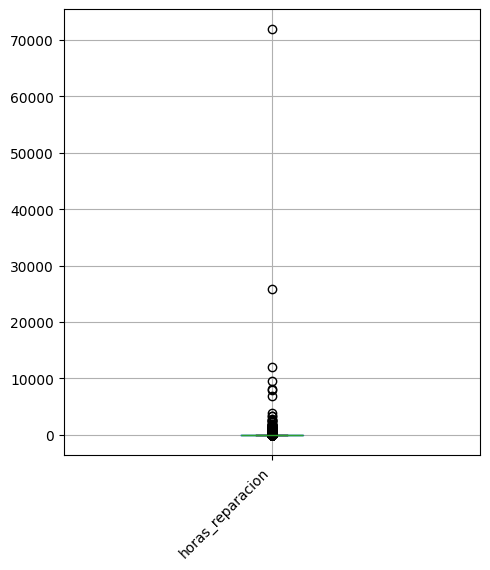

In [75]:
#horas en positivo. si se visualizan horas de 30 en positivo, por lo que puede deberse a un error de tipeo
df_h = df_test[['horas_reparacion']]
df_h[df_h['horas_reparacion'] > 0].boxplot(figsize=(5, 5))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [76]:
# Remplazamos valores negativos en horas_reparacion por su valor absoluto.
df_test_n['horas_reparacion'] = df_test_n['horas_reparacion'].abs()

In [77]:
#ante la existencia de un valor atipico, verificamos su indice
#71,851 horas de reparación ≈ 2,993.79 días. Eso serían unos 8 años, 2 meses y 24 días. No tiene sentido que lleve tantos años en reparación
#por lo que si pudo ser un error de tipeo
df_test_n[df_test_n['horas_reparacion']==df_test_n['horas_reparacion'].max()]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
2656,2656,Audi,R8,Grey,2016.0,Coupe,5000.0,5.2L,Automatic,Petrol,NaN,2.0,2.0,Radiator Leaking,0,2017-09-18,1,65204.822767,71851.662095,2017-10-10


In [78]:
#analizamos los valores de marcas y caracteristicas similares para ver con que valor podriamos reemplazar
df_test_n[(df_test_n['marca']== 'Audi') & (df_test_n['problema_averia']== 'Radiator Leaking') & (df_test_n['tipo_vehiculo']== 'Coupe') & (df_test_n['transmision']== 'Automatic') & (df_test_n['complejidad_reparacion']== 1)& (df_test_n['tipo_combustible']== 'Petrol')]


,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
136,136,Audi,R8,White,2008.0,Coupe,37500.0,4.2L,Automatic,Petrol,41995.0,2.0,2.0,Radiator Leaking,0,2018-04-11,1,879.900000,2.000000,2018-04-11
1234,1234,Audi,TTS,Black,2014.0,Coupe,18000.0,2.0L,Automatic,Petrol,21480.0,4.0,3.0,Radiator Leaking,0,2018-04-27,1,469.600000,2.000000,2018-04-27
1547,1547,Audi,S5,White,NaN,Coupe,62000.0,4.2L,Automatic,Petrol,15490.0,4.0,2.0,Radiator Leaking,0,2018-05-08,1,349.800000,2.000000,2018-05-08
2656,2656,Audi,R8,Grey,2016.0,Coupe,5000.0,5.2L,Automatic,Petrol,NaN,2.0,2.0,Radiator Leaking,0,2017-09-18,1,65204.822767,71851.662095,2017-10-10
4649,4649,Audi,TT,White,2016.0,Coupe,15711.0,2.0L,Automatic,Petrol,22800.0,4.0,3.0,Radiator Leaking,0,2018-08-13,1,496.000000,2.000000,2018-08-13
7634,7634,Audi,TTS,Black,2013.0,Coupe,48159.0,2.0L,Automatic,Petrol,19900.0,4.0,3.0,Radiator Leaking,0,2018-05-05,1,438.000000,2.000000,2018-05-05
9736,9736,Audi,TT,Red,2007.0,Coupe,100000.0,2.0L,Automatic,Petrol,5949.0,4.0,3.0,Radiator Leaking,0,2018-08-13,1,158.980000,2.000000,2018-08-13
11305,11305,Audi,S5,Black,2016.0,Coupe,23535.0,3.0L,Automatic,Petrol,23999.0,4.0,3.0,Radiator Leaking,0,2018-08-10,1,519.980000,2.000000,2018-08-10
13036,13036,Audi,TTS,White,2008.0,Coupe,58300.0,2.0L,Automatic,Petrol,12500.0,4.0,3.0,Radiator Leaking,0,2018-08-17,1,290.000000,2.000000,2018-08-17
17217,17217,Audi,A5,Black,2019.0,Coupe,16764.0,2.0L,Automatic,Petrol,22981.0,4.0,2.0,Radiator Leaking,0,2021-04-11,1,499.620000,2.000000,2021-04-11


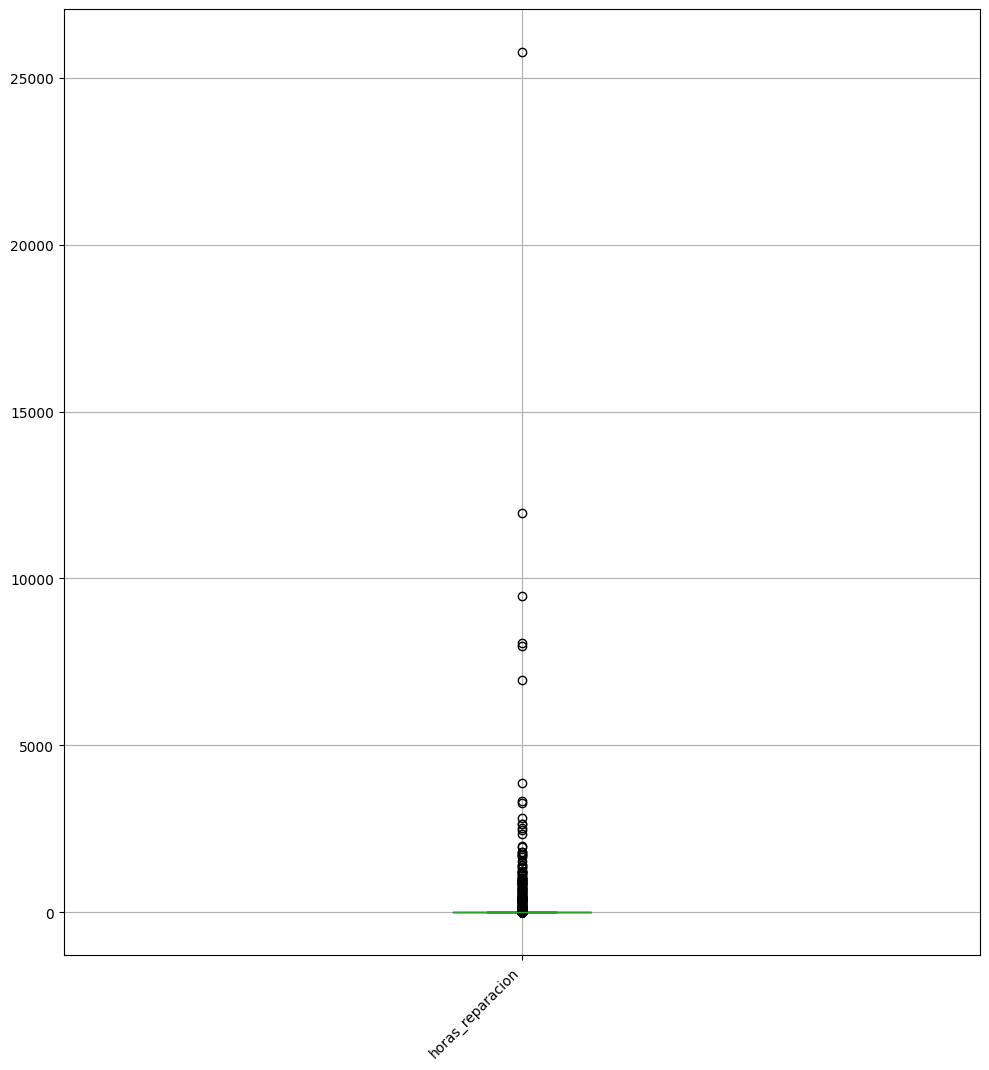

In [79]:
#reemplazamos la hora de repacion, a la hora de reparacion del grupo con caracteristicas similares
df_test_n.loc[2656, 'horas_reparacion'] = 2.0

#visualización de valores atípicos del dataset limpio
df_test_n[['horas_reparacion']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [80]:
#ante la existencia de OTRO valor atipico, verificamos su indice
#25,777.992569 horas ≈ 2 años, 343 días, 7 horas y 41 minutos. No tiene sentido que lleve tantos años en reparación
#por lo que si pudo ser un error de tipeo
df_test_n[df_test_n['horas_reparacion']==df_test_n['horas_reparacion'].max()]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
20654,20654,Audi,Q7,Black,2016.0,SUV,69000.0,3.0L,Automatic,Diesel,35995.0,7.0,5.0,Engine Issue,1,2018-02-04,1,32959.548317,25777.992569,2018-02-28


In [81]:
#analizamos los valores de marcas y caracteristicas similares para ver con que valor podriamos reemplazar
df_test_n[(df_test_n['marca']== 'Audi') & (df_test_n['problema_averia']== 'Engine Issue') & (df_test_n['tipo_vehiculo']== 'SUV') & (df_test_n['transmision']== 'Automatic') & (df_test_n['complejidad_reparacion']== 1)& (df_test_n['tipo_combustible']== 'Diesel')]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
5082,5082,Audi,Q3,Grey,2012.0,SUV,78956.0,2.0L,Automatic,Diesel,12495.0,5.0,5.0,Engine Issue,4,2018-08-17,1,824.750000,10.000000,2018-08-19
6655,6655,Audi,Q3,Blue,2015.0,SUV,41355.0,2.0L,Automatic,Diesel,19990.0,5.0,5.0,Engine Issue,1,2018-07-24,1,4158.000000,8.000000,2018-07-26
7947,7947,Audi,NaN,White,2015.0,SUV,34001.0,3.0L,Automatic,Diesel,30998.0,5.0,5.0,Engine Issue,2,2018-05-11,1,4969.700000,16.000000,2018-05-15
12079,12079,Audi,Q3,Gelb,2017.0,SUV,3451.0,2.0L,Automatic,Diesel,26000.0,5.0,5.0,Engine Issue,2,2018-05-22,1,4220.000000,16.000000,2018-05-26
13611,13611,Audi,Q5,White,2018.0,SUV,5000.0,2.0L,Automatic,Diesel,33853.0,5.0,5.0,Engine Issue,2,2018-07-17,1,5397.950000,16.000000,2018-07-21
16178,16178,Audi,Q7,Silver,2009.0,SUV,93000.0,3.0L,Automatic,Diesel,12495.0,7.0,5.0,Engine Issue,3,2018-07-19,1,1489.500000,12.000000,2018-07-22
16188,16188,Audi,Q7,Blue,2007.0,SUV,75000.0,3.0L,Automatic,Diesel,11990.0,7.0,5.0,Engine Issue,4,2018-04-15,1,799.500000,10.000000,2018-04-17
17306,17306,Audi,Q7,Grey,2010.0,SUV,122804.0,NaN,Automatic,Diesel,14989.0,7.0,5.0,Engine Issue,4,2018-04-15,1,949.450000,10.000000,2018-04-17
17520,17520,Audi,Q5,White,2019.0,SUV,13695.0,2.0L,Automatic,Diesel,36995.0,5.0,5.0,Engine Issue,3,2021-05-11,1,3939.500000,12.000000,2021-05-14
19199,19199,Audi,SQ5,Blue,2015.0,SUV,32372.0,3.0L,Automatic,Diesel,28645.0,5.0,5.0,Engine Issue,3,2018-06-05,1,3104.500000,12.000000,2018-06-08


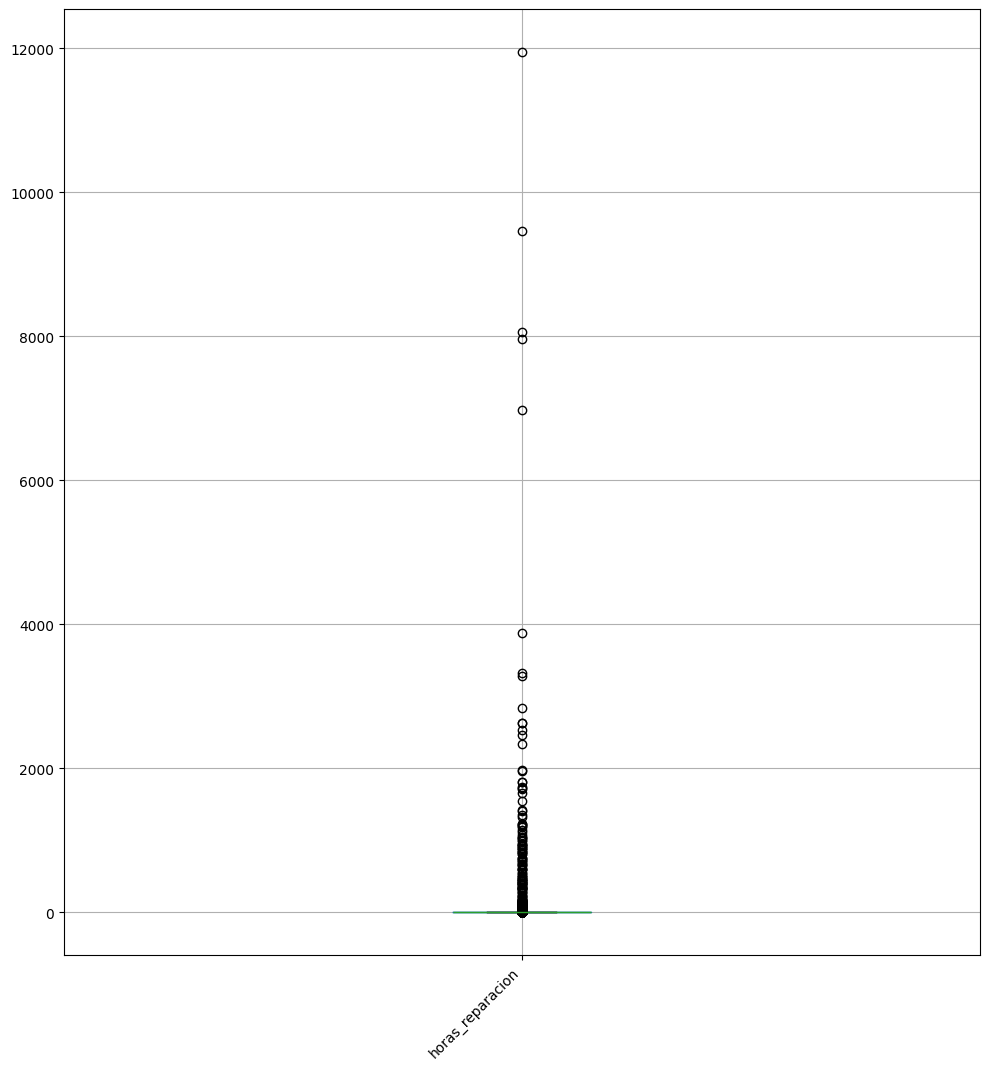

In [82]:
# Calculamos la media para los indices que tienen las mismas caracteristicas que el vehiculo con precio atipico y reemplazamos.
indices_to_average = [5082,6655,7947,12079,13611,16178,16188,17306,17520,19199,20105]
mean_hora = df_test_n.loc[indices_to_average, 'horas_reparacion'].mean()
mean_hora

# Remplazamos por la media
df_test_n.loc[20654, 'horas_reparacion'] = mean_hora

#visualización de valores atípicos del dataset limpio
df_test_n[['horas_reparacion']].boxplot(figsize=(10, 10))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

### Datos Faltantes

####df_train

#####Análisis de datos faltantes NaN (Not a Number) por filas

In [83]:
#analizar si tengo más del 70% de los valores de una fila con NaN

# Fijamos el límite de 70%
threshold = 0.7

# Calculamos el número de columnas en el df
num_cols = len(df_train_n.columns)

# Calculamos el limite de NaN en funcion del threshold y el num de columnas
null_threshold = int(threshold * num_cols)

# Contamos el numero de filas con NaN que exceden el limite estimado
num_rows_mostly_null = df_train_n[(df_train_n.isnull().sum(axis=1) >= null_threshold)].shape[0]

# El resultado es
print("Number of rows with mostly null values:", num_rows_mostly_null)

Number of rows with mostly null values: 0


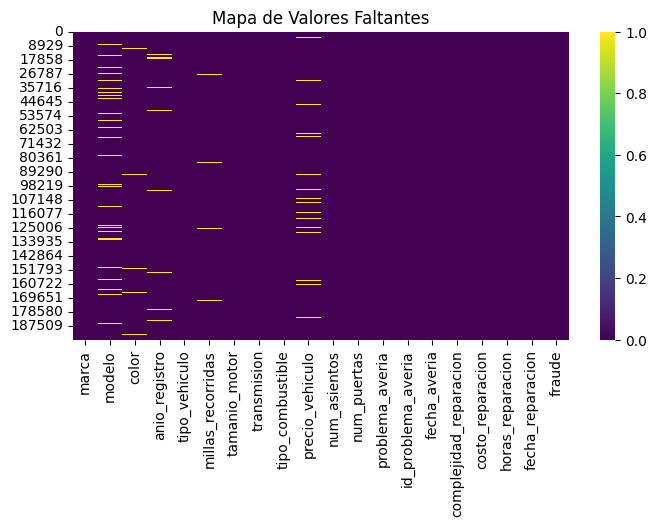

In [84]:
# visual
plt.figure(figsize=(8, 4))
sns.heatmap(df_train_n.isnull(), cbar=True, cmap="viridis")
plt.title("Mapa de Valores Faltantes")
plt.show()

#####Análisis de datos faltantes NaN (Not a Number) por columnas

In [85]:
#Porcentajes de NaN por columnas

# Calculate percentage of missing values in each column
missing_percentages = (df_train_n.isnull().sum() / len(df_train_n) * 100).round(2)

# Sort values in descending order to see columns with most missing values
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)

# Create a more descriptive output
print(f"Missing Values Analysis (Total rows: {len(df_train_n)})")

# Show all columns including those with 0% missing values
# Add percentage symbol to each value when displaying
print(missing_percentages_sorted.apply(lambda x: f"{x}%"))

Missing Values Analysis (Total rows: 196429)
modelo                     9.5%
precio_vehiculo           4.87%
color                     2.47%
anio_registro             2.46%
millas_recorridas         1.41%
tamanio_motor             0.48%
marca                      0.0%
tipo_vehiculo              0.0%
transmision                0.0%
tipo_combustible           0.0%
num_asientos               0.0%
num_puertas                0.0%
problema_averia            0.0%
id_problema_averia         0.0%
fecha_averia               0.0%
complejidad_reparacion     0.0%
costo_reparacion           0.0%
horas_reparacion           0.0%
fecha_reparacion           0.0%
fraude                     0.0%
dtype: object


###### variables continuas: anio_registro, millas_recorridas, precio_vehiculo

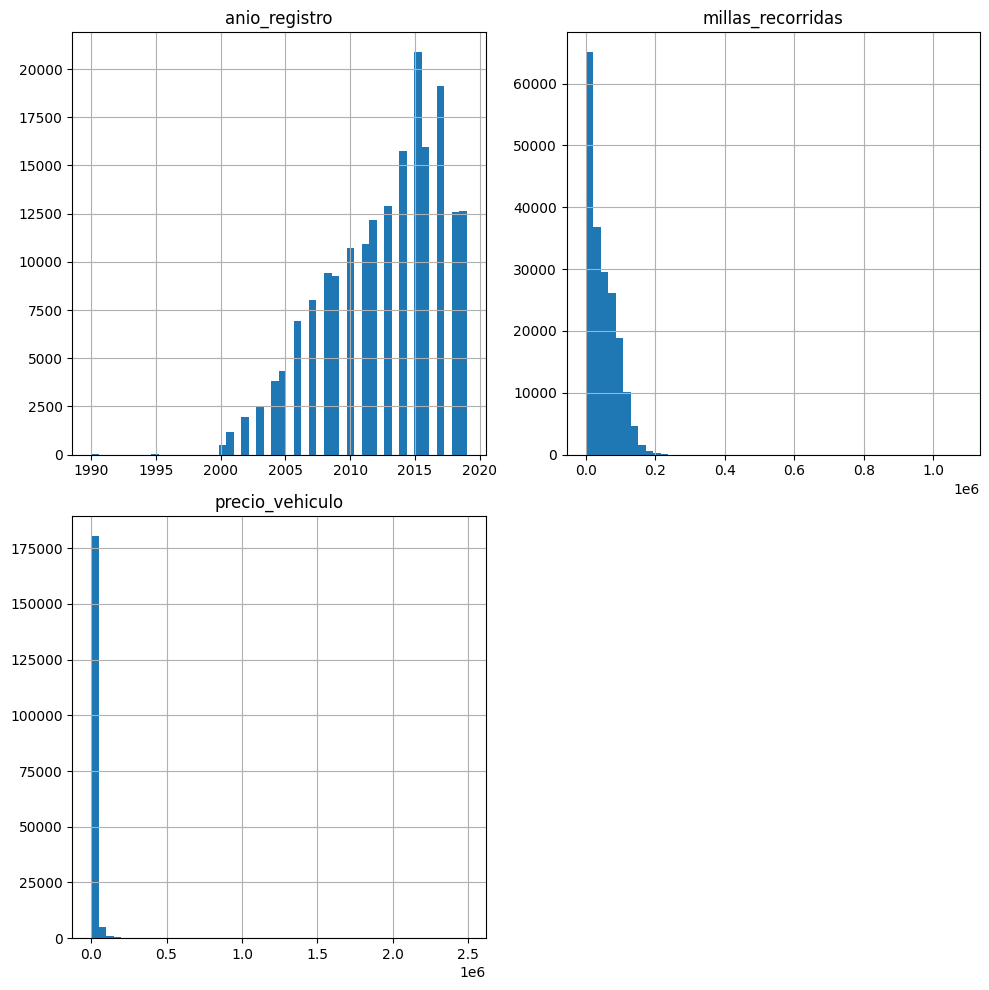

In [86]:
#distribución del dataset train numericas
df_train_n[['anio_registro','millas_recorridas','precio_vehiculo']].hist(bins=50, figsize=(10,10))
plt.tight_layout()
plt.show()

<Axes: >

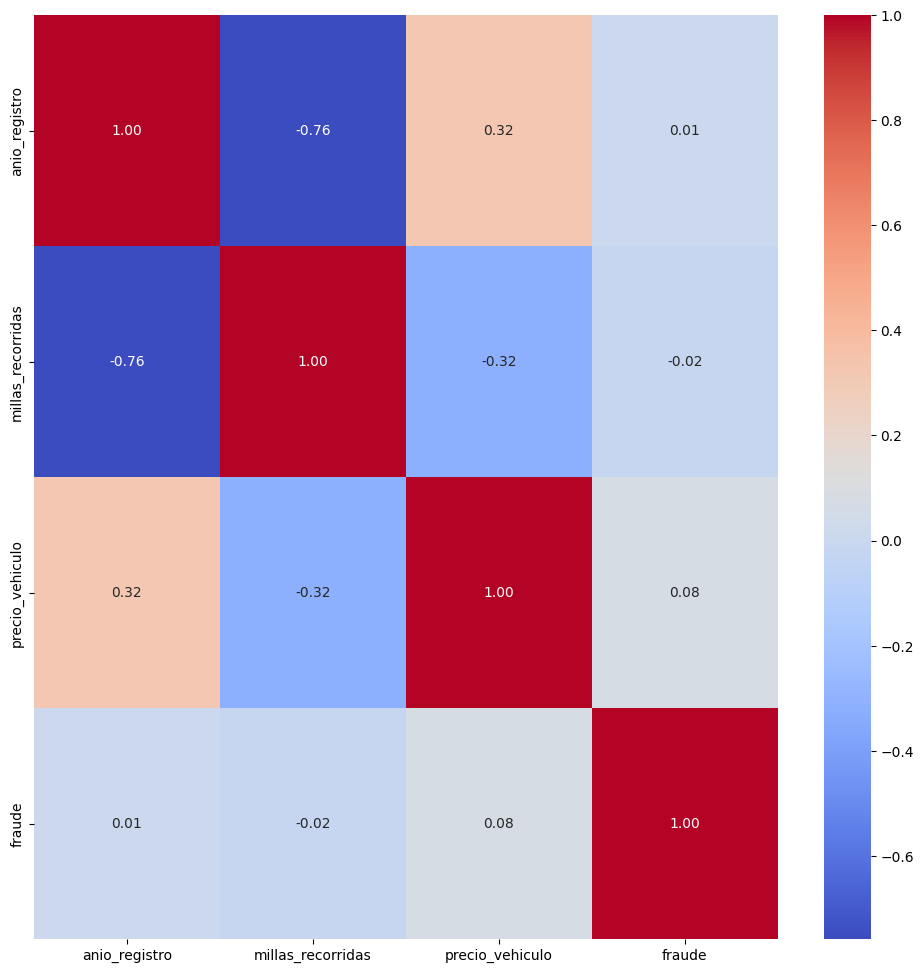

In [87]:
corr_matrix = df_train_n[['anio_registro','millas_recorridas','precio_vehiculo','fraude']].corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

Dada la distribución se buscará imputar con la mediana o con el KNN Imputer.

In [88]:
df_train_n[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

,anio_registro,millas_recorridas,precio_vehiculo
count,191599.000000,1.936640e+05,1.868670e+05
mean,2012.673641,4.868746e+04,1.439410e+04
std,4.450971,4.003550e+04,2.339137e+04
min,1990.000000,0.000000e+00,1.000000e+02
25%,2009.000000,1.465575e+04,4.799000e+03
50%,2014.000000,4.000000e+04,9.000000e+03
75%,2016.000000,7.557125e+04,1.698900e+04
max,2019.000000,1.080000e+06,2.490000e+06


In [89]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

#Imputacion mediante KNN Imputer
colums_imputed = ['anio_registro','millas_recorridas','precio_vehiculo']

scaler = MinMaxScaler()
df_imputed = df_train_n.copy()
scaled_data = scaler.fit_transform(df_imputed[colums_imputed])

imputer = KNNImputer(n_neighbors=3)
imputed_data = imputer.fit_transform(scaled_data)

df_imputed[colums_imputed] = scaler.inverse_transform(imputed_data)
df_imputed[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

,anio_registro,millas_recorridas,precio_vehiculo
count,196429.000000,1.964290e+05,1.964290e+05
mean,2012.669080,4.868984e+04,1.440778e+04
std,4.438580,3.996259e+04,2.302842e+04
min,1990.000000,0.000000e+00,1.000000e+02
25%,2009.333333,1.468800e+04,4.900000e+03
50%,2014.000000,4.000000e+04,9.144000e+03
75%,2016.000000,7.564300e+04,1.699500e+04
max,2019.000000,1.080000e+06,2.490000e+06


In [90]:
#Imputacion con mediana
df_imputed_m = df_train_n.copy()

for col in colums_imputed:
    mediana = df_imputed_m[col].median()
    df_imputed_m[col].fillna(mediana, inplace=True)

df_imputed_m[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

C:\Users\smithinator\AppData\Local\Temp\ipykernel_17092\3605107388.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_m[col].fillna(mediana, inplace=True)
C:\Users\smithinator\AppData\Local\Temp\ipykernel_17092\3605107388.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

,anio_registro,millas_recorridas,precio_vehiculo
count,196429.000000,1.964290e+05,1.964290e+05
mean,2012.706255,4.856517e+04,1.413152e+04
std,4.400704,3.976590e+04,2.284444e+04
min,1990.000000,0.000000e+00,1.000000e+02
25%,2010.000000,1.494900e+04,4.995000e+03
50%,2014.000000,4.000000e+04,9.000000e+03
75%,2016.000000,7.500000e+04,1.621400e+04
max,2019.000000,1.080000e+06,2.490000e+06


Dado que se visualizan distribuciones mucho más similares al dataset original con el método de KNNImputer, se imputará los datos faltantes de estas variables con este modelo.

In [91]:
df_train_n = df_imputed_m.copy()

######variables categoricas: modelo, color, tamanio_motor

Modelo

In [92]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_train_n[df_train_n['modelo'].isna()][['modelo','marca','anio_registro','tipo_vehiculo','tamanio_motor','transmision',
  'tipo_combustible','num_asientos','num_puertas']]

,modelo,marca,anio_registro,tipo_vehiculo,tamanio_motor,transmision,tipo_combustible,num_asientos,num_puertas
3,NaN,Renault,2014.0,Hatchback,1.2L,Manual,Petrol,5.0,5.0
10,NaN,Vauxhall,2011.0,Hatchback,2.0L,Manual,Diesel,5.0,5.0
40,NaN,Volvo,2014.0,Hatchback,1.6L,Manual,Diesel,5.0,5.0
62,NaN,Porsche,2016.0,SUV,3.0L,Automatic,Diesel,5.0,5.0
75,NaN,Mercedes-Benz,2007.0,Convertible,1.8L,Automatic,Petrol,4.0,2.0
...,...,...,...,...,...,...,...,...,...
196387,NaN,Vauxhall,2017.0,Hatchback,1.4L,Manual,Petrol,5.0,3.0
196390,NaN,Volkswagen,2009.0,Hatchback,2.0L,Manual,Diesel,5.0,5.0
196396,NaN,Renault,2019.0,SUV,1.3L,Manual,Petrol,5.0,5.0
196414,NaN,Ford,2018.0,Hatchback,1.0L,Manual,Petrol,5.0,5.0


In [93]:
#se visualiza que en base a estas caracteristicas, solo se observa el modelo es Clio, este valor deberiamos reemplazar en el NaN
#este ejercicio lo deberiamos repetir para todos los atributos...
df_train_n[
    (df_train_n['marca'] == 'Renault') &
    (df_train_n['anio_registro'] == 2014.0) &
    (df_train_n['tipo_vehiculo'] == 'Hatchback') &
    (df_train_n['tamanio_motor'] == '1.2L') &
    (df_train_n['transmision'] == 'Manual') &
    (df_train_n['tipo_combustible'] == 'Petrol') &
    (df_train_n['num_asientos'] == 5.0) &
    (df_train_n['num_puertas'] == 5.0) &
    (df_train_n['modelo'].notna())
]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
5998,Renault,Clio,White,2014.0,Hatchback,37500.0,1.2L,Manual,Petrol,6995.0,5.0,5.0,Gear Box Issue,0,2018-05-02,1,109.9500,2.0,2018-05-02,0
8005,Renault,Clio,White,2014.0,Hatchback,11130.0,1.2L,Manual,Petrol,9000.0,5.0,5.0,Sensor Malfunction,0,2018-05-06,1,510.0000,3.0,2018-05-06,0
11234,Renault,Clio,Grey,2014.0,Hatchback,18445.0,1.2L,Manual,Petrol,6300.0,5.0,5.0,Tyre Alignment,0,2018-08-04,1,10.6300,0.5,2018-08-04,0
13301,Renault,Clio,Grey,2014.0,Hatchback,35245.0,1.2L,Manual,Petrol,6498.0,5.0,5.0,Radiator Leaking,0,2018-04-01,1,169.9600,2.0,2018-04-01,0
14803,Renault,Clio,Blue,2014.0,Hatchback,59391.0,1.2L,Manual,Petrol,5999.0,5.0,5.0,Gear Box Issue,0,2018-08-01,1,99.9900,2.0,2018-08-01,0
16622,Renault,Clio,Red,2014.0,Hatchback,13000.0,1.2L,Manual,Petrol,7175.0,5.0,5.0,Alternator Failing,0,2018-08-13,1,183.5000,2.0,2018-08-13,0
21365,Renault,Clio,Black,2014.0,Hatchback,12000.0,1.2L,Manual,Petrol,7600.0,5.0,5.0,Steering Wheel Shaking,0,2018-04-04,1,27.6000,1.0,2018-04-04,0
23122,Renault,Clio,White,2014.0,Hatchback,49730.0,1.2L,Manual,Petrol,6500.0,5.0,5.0,Brake Pads Worn,0,2018-04-19,1,43.2500,2.0,2018-04-19,0
23871,Renault,Clio,Silver,2014.0,Hatchback,18000.0,1.2L,Manual,Petrol,6250.0,5.0,5.0,Alternator Failing,0,2018-07-27,1,165.0000,2.0,2018-07-27,0
24999,Renault,Clio,Grey,2014.0,Hatchback,36157.0,1.2L,Manual,Petrol,5995.0,5.0,5.0,Starter Motor Issue,0,2018-08-01,1,119.9500,3.0,2018-08-01,0


In [94]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo','tamanio_motor','transmision',
  'tipo_combustible','num_asientos','num_puertas']

#Creamos una función para obtener la moda
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else np.nan

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_train_n['modelo'] = df_train_n['modelo'].fillna(
    df_train_n.groupby(columnas_relacionadas)['modelo'].transform(get_mode)
)

In [95]:
#verificamos que se haya modificamo como queremos
df_train_n.loc[3]

marca                             Renault
modelo                               Clio
color                                 NaN
anio_registro                      2014.0
tipo_vehiculo                   Hatchback
millas_recorridas                 20669.0
tamanio_motor                        1.2L
transmision                        Manual
tipo_combustible                   Petrol
precio_vehiculo                    6950.0
num_asientos                          5.0
num_puertas                           5.0
problema_averia           Brake Pads Worn
id_problema_averia                      0
fecha_averia                   2018-04-23
complejidad_reparacion                  1
costo_reparacion                   43.475
horas_reparacion                      2.0
fecha_reparacion               2018-04-23
fraude                                  0
Name: 3, dtype: object

In [96]:
df_train_n['modelo'].isna().sum()


np.int64(629)

In [97]:
#Rellenamos lo que queda con la moda general
df_train_n['modelo'] = df_train_n['modelo'].fillna(df_train_n['modelo'].mode()[0])

In [98]:
df_train_n['modelo'].isna().sum()

np.int64(0)

Color

In [99]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_train_n[df_train_n['color'].isna()][['color','marca','anio_registro','tipo_vehiculo','transmision','tipo_combustible','num_asientos',
    'num_puertas']]

,color,marca,anio_registro,tipo_vehiculo,transmision,tipo_combustible,num_asientos,num_puertas
3,NaN,Renault,2014.0,Hatchback,Manual,Petrol,5.0,5.0
4,NaN,Ford,2007.0,MPV,Manual,Petrol,5.0,5.0
68,NaN,Mercedes-Benz,2014.0,Convertible,Automatic,Petrol,2.0,2.0
74,NaN,Peugeot,2017.0,Hatchback,Manual,Petrol,4.0,3.0
127,NaN,Audi,2016.0,Saloon,Manual,Diesel,5.0,4.0
...,...,...,...,...,...,...,...,...
196232,NaN,Vauxhall,2013.0,MPV,Manual,Petrol,7.0,5.0
196264,NaN,Mazda,2014.0,Saloon,Manual,Petrol,5.0,4.0
196292,NaN,Volvo,2011.0,Coupe,Manual,Petrol,4.0,2.0
196403,NaN,SKODA,2015.0,Hatchback,Manual,Petrol,5.0,5.0


In [100]:
#se visualiza que en base a estas caracteristicas, hay muchos colores, por lo que deberiamos reemplazar en el NaN con la moda
#este ejercicio lo deberiamos repetir para todos los atributos...
df_train_n[
    (df_train_n['marca'] == 'Renault') &
    (df_train_n['anio_registro'] == 2014.0) &
    (df_train_n['tipo_vehiculo'] == 'Hatchback') &
    (df_train_n['transmision'] == 'Manual') &
    (df_train_n['tipo_combustible'] == 'Petrol') &
    (df_train_n['num_asientos'] == 5.0) &
    (df_train_n['num_puertas'] == 5.0) &
    (df_train_n['color'].notna())
]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
3782,Renault,Clio,Red,2014.0,Hatchback,8675.0,0.9L,Manual,Petrol,5995.0,5.0,5.0,Warning Light,0,2018-07-13,1,239.9500,9.0,2018-07-15,0
5927,Renault,Clio,Silver,2014.0,Hatchback,22915.0,0.9L,Manual,Petrol,7576.0,5.0,5.0,Windscreen Crack,0,2018-04-21,1,24.5456,1.0,2018-04-21,0
5998,Renault,Clio,White,2014.0,Hatchback,37500.0,1.2L,Manual,Petrol,6995.0,5.0,5.0,Gear Box Issue,0,2018-05-02,1,109.9500,2.0,2018-05-02,0
8005,Renault,Clio,White,2014.0,Hatchback,11130.0,1.2L,Manual,Petrol,9000.0,5.0,5.0,Sensor Malfunction,0,2018-05-06,1,510.0000,3.0,2018-05-06,0
11234,Renault,Clio,Grey,2014.0,Hatchback,18445.0,1.2L,Manual,Petrol,6300.0,5.0,5.0,Tyre Alignment,0,2018-08-04,1,10.6300,0.5,2018-08-04,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191941,Renault,Clio,Yellow,2014.0,Hatchback,43000.0,1.2L,Manual,Petrol,6795.0,5.0,5.0,Radiator Leaking,0,2018-06-27,1,175.9000,2.0,2018-06-27,0
192837,Renault,Clio,White,2014.0,Hatchback,40000.0,1.2L,Manual,Petrol,6495.0,5.0,5.0,Tyre Alignment,0,2018-04-11,1,10.6495,0.5,2018-04-11,0
193656,Renault,Clio,Silver,2014.0,Hatchback,22032.0,1.2L,Manual,Petrol,7495.0,5.0,5.0,Warning Light,0,2018-04-18,1,254.9500,9.0,2018-04-20,0
195232,Renault,Clio,Silver,2014.0,Hatchback,24559.0,0.9L,Manual,Petrol,7700.0,5.0,5.0,Transmission Issue,2,2018-05-07,1,113.9000,3.0,2018-05-07,0


In [101]:
#moda
df_train_n[
    (df_train_n['marca'] == 'Renault') &
    (df_train_n['anio_registro'] == 2014.0) &
    (df_train_n['tipo_vehiculo'] == 'Hatchback') &
    (df_train_n['transmision'] == 'Manual') &
    (df_train_n['tipo_combustible'] == 'Petrol') &
    (df_train_n['num_asientos'] == 5.0) &
    (df_train_n['num_puertas'] == 5.0) &
    (df_train_n['color'].notna())
]['color'].mode()

0    White
Name: color, dtype: object

In [102]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo','transmision','tipo_combustible','num_asientos',
    'num_puertas']

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_train_n['color'] = df_train_n['color'].fillna(
    df_train_n.groupby(columnas_relacionadas)['color'].transform(get_mode)
)

In [103]:
#verificamos que se haya modificamo como queremos
df_train_n.loc[3]

marca                             Renault
modelo                               Clio
color                               White
anio_registro                      2014.0
tipo_vehiculo                   Hatchback
millas_recorridas                 20669.0
tamanio_motor                        1.2L
transmision                        Manual
tipo_combustible                   Petrol
precio_vehiculo                    6950.0
num_asientos                          5.0
num_puertas                           5.0
problema_averia           Brake Pads Worn
id_problema_averia                      0
fecha_averia                   2018-04-23
complejidad_reparacion                  1
costo_reparacion                   43.475
horas_reparacion                      2.0
fecha_reparacion               2018-04-23
fraude                                  0
Name: 3, dtype: object

In [104]:
df_train_n['color'].isna().sum()

np.int64(81)

In [105]:
#Rellenamos lo que queda con la moda general
df_train_n['color'] = df_train_n['color'].fillna(df_train_n['color'].mode()[0])

In [106]:
df_train_n['color'].isna().sum()

np.int64(0)

Tamanio_motor

In [107]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_train_n[df_train_n['tamanio_motor'].isna()][['tamanio_motor','marca','anio_registro','tipo_vehiculo',
    'transmision','tipo_combustible','num_asientos','num_puertas']]

,tamanio_motor,marca,anio_registro,tipo_vehiculo,transmision,tipo_combustible,num_asientos,num_puertas
1,NaN,Vauxhall,2011.0,Hatchback,Manual,Petrol,5.0,5.0
204,NaN,Infiniti,2011.0,SUV,Automatic,Diesel,5.0,5.0
246,NaN,Vauxhall,2014.0,Hatchback,Manual,Petrol,5.0,3.0
397,NaN,Bentley,2017.0,SUV,Automatic,Diesel,5.0,5.0
1057,NaN,Mercedes-Benz,2018.0,Hatchback,Manual,Petrol,5.0,5.0
...,...,...,...,...,...,...,...,...
195526,NaN,Kia,2017.0,Saloon,Automatic,Diesel,5.0,4.0
195715,NaN,Volvo,2017.0,Saloon,Automatic,Diesel,5.0,4.0
195813,NaN,Mercedes-Benz,2019.0,SUV,Manual,Petrol,5.0,5.0
196145,NaN,Jaguar,2015.0,Saloon,Automatic,Diesel,5.0,4.0


In [108]:
#se visualiza que en base a estas caracteristicas, hay muchos tamanio_motor, por lo que deberiamos reemplazar en el NaN con la moda
#este ejercicio lo deberiamos repetir para todos los atributos...
df_train_n[
    (df_train_n['marca'] == 'Vauxhall') &
    (df_train_n['anio_registro'] == 2011.0) &
    (df_train_n['tipo_vehiculo'] == 'Hatchback') &
    (df_train_n['transmision'] == 'Manual') &
    (df_train_n['tipo_combustible'] == 'Petrol') &
    (df_train_n['num_asientos'] == 5.0) &
    (df_train_n['num_puertas'] == 5.0) &
    (df_train_n['tamanio_motor'].notna())
]

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion,fraude
804,Vauxhall,Corsa,Red,2011.0,Hatchback,45000.0,1.2L,Manual,Petrol,4500.0,5.0,5.0,Flat Tyres,0,2018-05-13,1,21.3500,1.0,2018-05-13,0
1105,Vauxhall,Corsa,White,2011.0,Hatchback,69955.0,1.2L,Manual,Petrol,3995.0,5.0,5.0,Tyre Alignment,0,2018-07-02,1,10.3995,0.5,2018-07-02,0
1517,Vauxhall,Corsa,Red,2011.0,Hatchback,74850.0,1.0L,Manual,Petrol,3375.0,5.0,5.0,Excessive Emissions,0,2018-08-02,1,23.0375,1.0,2018-08-02,0
1663,Vauxhall,Agila,White,2011.0,Hatchback,24437.0,1.2L,Manual,Petrol,4500.0,5.0,5.0,Steering Wheel Shaking,0,2018-08-13,1,24.5000,1.0,2018-08-13,0
2443,Vauxhall,Corsa,Silver,2011.0,Hatchback,82483.0,1.2L,Manual,Petrol,3350.0,5.0,5.0,Tyre Alignment,0,2018-03-09,1,10.3350,0.5,2018-03-09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194641,Vauxhall,Corsa,Silver,2011.0,Hatchback,64000.0,1.2L,Manual,Petrol,3495.0,5.0,5.0,Alternator Failing,0,2018-08-21,1,109.9000,2.0,2018-08-21,0
195275,Vauxhall,Corsa,Silver,2011.0,Hatchback,63139.0,1.4L,Manual,Petrol,9000.0,5.0,5.0,Steering Wheel Shaking,0,2018-08-25,1,24.6900,1.0,2018-08-25,0
195320,Vauxhall,Corsa,Green,2011.0,Hatchback,40595.0,1.4L,Manual,Petrol,4800.0,5.0,5.0,Flat Tyres,0,2018-08-16,1,21.4400,1.0,2018-08-16,0
195442,Vauxhall,Corsa,Blue,2011.0,Hatchback,90819.0,1.2L,Manual,Petrol,2790.0,5.0,5.0,Radiator Leaking,0,2018-01-24,1,95.8000,2.0,2018-01-24,0


In [109]:
#la moda
df_train_n[
    (df_train_n['marca'] == 'Vauxhall') &
    (df_train_n['anio_registro'] == 2011.0) &
    (df_train_n['tipo_vehiculo'] == 'Hatchback') &
    (df_train_n['transmision'] == 'Manual') &
    (df_train_n['tipo_combustible'] == 'Petrol') &
    (df_train_n['num_asientos'] == 5.0) &
    (df_train_n['num_puertas'] == 5.0) &
    (df_train_n['tamanio_motor'].notna())
]['tamanio_motor'].mode()

0    1.2L
Name: tamanio_motor, dtype: object

In [110]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo',
    'transmision','tipo_combustible','num_asientos','num_puertas']

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_train_n['tamanio_motor'] = df_train_n['tamanio_motor'].fillna(
    df_train_n.groupby(columnas_relacionadas)['tamanio_motor'].transform(get_mode)
)

In [111]:
#verificamos que se haya modificamo como queremos
df_train_n.loc[1]

marca                                Vauxhall
modelo                               Insignia
color                                    Grey
anio_registro                          2011.0
tipo_vehiculo                       Hatchback
millas_recorridas                     93000.0
tamanio_motor                            1.2L
transmision                            Manual
tipo_combustible                       Petrol
precio_vehiculo                        3995.0
num_asientos                              5.0
num_puertas                               5.0
problema_averia           Excessive Emissions
id_problema_averia                          0
fecha_averia                       2018-08-09
complejidad_reparacion                      1
costo_reparacion                      23.5955
horas_reparacion                          1.0
fecha_reparacion                   2018-08-09
fraude                                      0
Name: 1, dtype: object

In [112]:
df_train_n['tamanio_motor'].isna().sum()

np.int64(20)

In [113]:
#Rellenamos lo que queda con la moda general
df_train_n['tamanio_motor'] = df_train_n['tamanio_motor'].fillna(df_train_n['tamanio_motor'].mode()[0])

In [114]:
df_train_n['tamanio_motor'].isna().sum()

np.int64(0)

####df_test

#####Análisis de datos faltantes NaN (Not a Number) por filas

In [115]:
#analizar si tengo más del 70% de los valores de una fila con NaN

# Fijamos el límite de 70%
threshold = 0.7

# Calculamos el número de columnas en el df
num_cols = len(df_test_n.columns)

# Calculamos el limite de NaN en funcion del threshold y el num de columnas
null_threshold = int(threshold * num_cols)

# Contamos el numero de filas con NaN que exceden el limite estimado
num_rows_mostly_null = df_test_n[(df_test_n.isnull().sum(axis=1) >= null_threshold)].shape[0]

# El resultado es
print("Number of rows with mostly null values:", num_rows_mostly_null)

Number of rows with mostly null values: 0


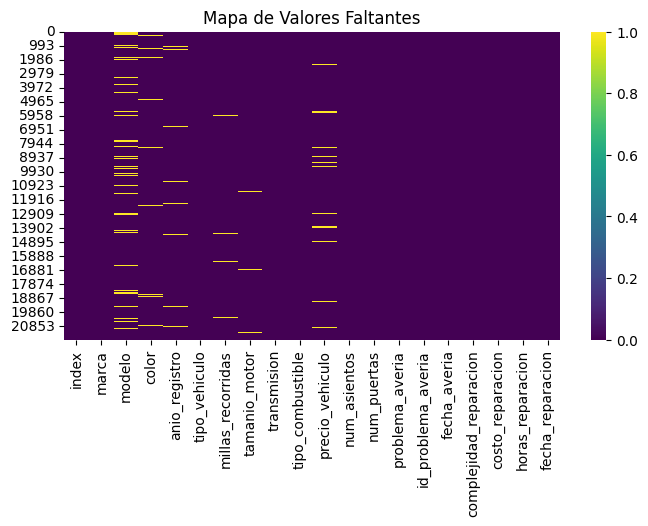

In [116]:
# visual
plt.figure(figsize=(8, 4))
sns.heatmap(df_test_n.isnull(), cbar=True, cmap="viridis")
plt.title("Mapa de Valores Faltantes")
plt.show()

##### Análisis de datos faltantes NaN (Not a Number) por columnas

In [117]:
#Porcentajes de NaN por columnas

# Calculate percentage of missing values in each column
missing_percentages = (df_test_n.isnull().sum() / len(df_test_n) * 100).round(2)

# Sort values in descending order to see columns with most missing values
missing_percentages_sorted = missing_percentages.sort_values(ascending=False)

# Create a more descriptive output
print(f"Missing Values Analysis (Total rows: {len(df_test_n)})")

# Show all columns including those with 0% missing values
# Add percentage symbol to each value when displaying
print(missing_percentages_sorted.apply(lambda x: f"{x}%"))

Missing Values Analysis (Total rows: 21826)
modelo                    9.65%
precio_vehiculo           4.68%
color                      2.5%
anio_registro             2.42%
millas_recorridas         1.45%
tamanio_motor              0.5%
index                      0.0%
marca                      0.0%
tipo_vehiculo              0.0%
transmision                0.0%
tipo_combustible           0.0%
num_asientos               0.0%
num_puertas                0.0%
problema_averia            0.0%
id_problema_averia         0.0%
fecha_averia               0.0%
complejidad_reparacion     0.0%
costo_reparacion           0.0%
horas_reparacion           0.0%
fecha_reparacion           0.0%
dtype: object


###### variables continuas: anio_registro, millas_recorridas, precio_vehiculo

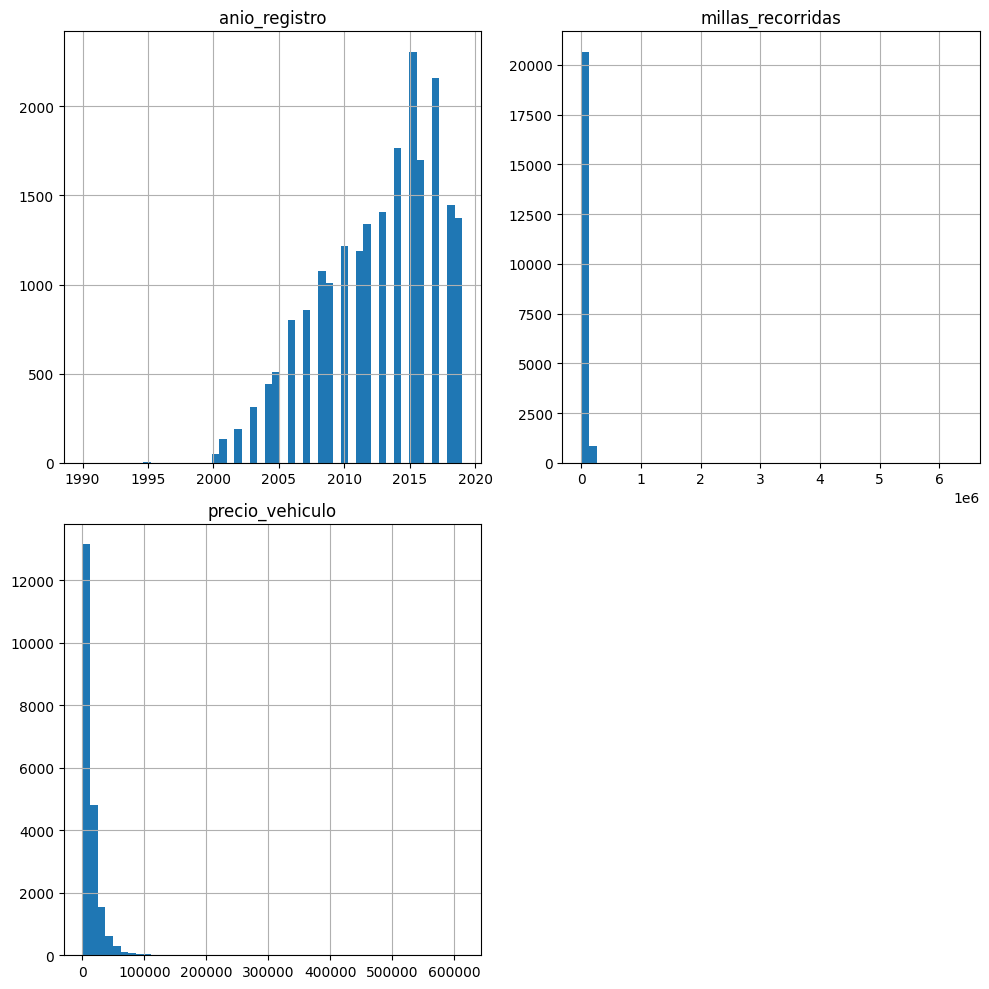

In [118]:
#distribución del dataset train numericas
df_test_n[['anio_registro','millas_recorridas','precio_vehiculo']].hist(bins=50, figsize=(10,10))
plt.tight_layout()
plt.show()

In [119]:
df_test_n[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

,anio_registro,millas_recorridas,precio_vehiculo
count,21298.000000,2.151000e+04,20805.000000
mean,2012.642173,4.921120e+04,14163.806537
std,4.474466,5.912943e+04,20221.460224
min,1990.000000,0.000000e+00,150.000000
25%,2009.000000,1.449375e+04,4747.000000
50%,2014.000000,4.005400e+04,8995.000000
75%,2016.000000,7.600000e+04,16950.000000
max,2019.000000,6.363342e+06,612718.000000


In [120]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

#Imputacion mediante KNN Imputer
colums_imputed = ['anio_registro','millas_recorridas','precio_vehiculo']

scaler = MinMaxScaler()
df_imputed = df_test_n.copy()
scaled_data = scaler.fit_transform(df_imputed[colums_imputed])

imputer = KNNImputer(n_neighbors=3)
imputed_data = imputer.fit_transform(scaled_data)

df_imputed[colums_imputed] = scaler.inverse_transform(imputed_data)
df_imputed[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

,anio_registro,millas_recorridas,precio_vehiculo
count,21826.000000,2.182600e+04,21826.000000
mean,2012.641055,4.919253e+04,14166.395186
std,4.462818,5.882792e+04,19931.868883
min,1990.000000,0.000000e+00,150.000000
25%,2009.000000,1.450000e+04,4750.000000
50%,2014.000000,4.038400e+04,9000.000000
75%,2016.000000,7.600000e+04,16990.000000
max,2019.000000,6.363342e+06,612718.000000


In [121]:
#Imputacion con mediana
df_imputed_m = df_test_n.copy()

for col in colums_imputed:
    mediana = df_imputed_m[col].median()
    df_imputed_m[col].fillna(mediana, inplace=True)

df_imputed_m[['anio_registro','millas_recorridas','precio_vehiculo']].describe()

C:\Users\smithinator\AppData\Local\Temp\ipykernel_17092\1016127367.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_m[col].fillna(mediana, inplace=True)
C:\Users\smithinator\AppData\Local\Temp\ipykernel_17092\1016127367.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

,anio_registro,millas_recorridas,precio_vehiculo
count,21826.000000,2.182600e+04,21826.000000
mean,2012.675021,4.907862e+04,13922.014570
std,4.424932,5.871000e+04,19772.952069
min,1990.000000,0.000000e+00,150.000000
25%,2010.000000,1.472075e+04,4990.000000
50%,2014.000000,4.005400e+04,8995.000000
75%,2016.000000,7.550000e+04,16000.000000
max,2019.000000,6.363342e+06,612718.000000


Dado que se visualizan distribuciones mucho más similares al dataset original con el método de KNNImputer, se imputará los datos faltantes de estas variables con este modelo.

In [122]:
df_test_n = df_imputed_m.copy()

###### variables categoricas: modelo, color, tamanio_motor

Modelo

In [123]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_test_n[df_test_n['modelo'].isna()][['modelo','marca','anio_registro','tipo_vehiculo','tamanio_motor','transmision',
  'tipo_combustible','num_asientos','num_puertas']]

,modelo,marca,anio_registro,tipo_vehiculo,tamanio_motor,transmision,tipo_combustible,num_asientos,num_puertas
6,NaN,Porsche,2015.0,Coupe,3.8L,Automatic,Petrol,4.0,2.0
8,NaN,Renault,2014.0,Hatchback,1.2L,Manual,Petrol,5.0,5.0
11,NaN,Citroen,2011.0,MPV,1.6L,Automatic,Diesel,7.0,5.0
14,NaN,Renault,2011.0,MPV,1.6L,Manual,Petrol,5.0,5.0
18,NaN,MINI,2008.0,Hatchback,1.4L,Manual,Petrol,4.0,3.0
...,...,...,...,...,...,...,...,...,...
21783,NaN,Nissan,2012.0,SUV,1.5L,Manual,Diesel,5.0,5.0
21784,NaN,Jaguar,2017.0,SUV,2.0L,Automatic,Diesel,5.0,5.0
21807,NaN,SKODA,2014.0,Hatchback,1.6L,Manual,Diesel,5.0,5.0
21812,NaN,SEAT,2018.0,SUV,1.0L,Manual,Petrol,5.0,5.0


In [124]:
#se visualiza que en base a estas caracteristicas, solo se observa el modelo es Porsche, este valor deberiamos reemplazar en el NaN
#este ejercicio lo deberiamos repetir para todos los atributos...
df_test_n[
    (df_test_n['marca'] == 'Porsche') &
    (df_test_n['anio_registro'] == 2015.0) &
    (df_test_n['tipo_vehiculo'] == 'Coupe') &
    (df_test_n['tamanio_motor'] == '3.8L') &
    (df_test_n['transmision'] == 'Automatic') &
    (df_test_n['tipo_combustible'] == 'Petrol') &
    (df_test_n['num_asientos'] == 4.0) &
    (df_test_n['num_puertas'] == 2.0) &
    (df_test_n['modelo'].notna())
]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
3432,3432,Porsche,911,Blue,2015.0,Coupe,6700.0,3.8L,Automatic,Petrol,91950.0,4.0,2.0,Windscreen Crack,0,2018-03-11,3,115.17,3.0,2018-03-11
14937,14937,Porsche,911,Blue,2015.0,Coupe,6800.0,3.8L,Automatic,Petrol,115000.0,4.0,2.0,Gear Box Issue,0,2018-05-20,3,1270.00,6.0,2018-05-21


In [125]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo','tamanio_motor','transmision',
  'tipo_combustible','num_asientos','num_puertas']

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_test_n['modelo'] = df_test_n['modelo'].fillna(
    df_test_n.groupby(columnas_relacionadas)['modelo'].transform(get_mode)
)

In [126]:
#verificamos que si se reemplazo con la moda
df_test_n.loc[6]

index                                  6
marca                            Porsche
modelo                               911
color                              White
anio_registro                     2015.0
tipo_vehiculo                      Coupe
millas_recorridas                 4300.0
tamanio_motor                       3.8L
transmision                    Automatic
tipo_combustible                  Petrol
precio_vehiculo                 127995.0
num_asientos                         4.0
num_puertas                          2.0
problema_averia           Tyre Alignment
id_problema_averia                     0
fecha_averia                  2018-03-27
complejidad_reparacion                 3
costo_reparacion                 42.7995
horas_reparacion                     1.5
fecha_reparacion              2018-03-27
Name: 6, dtype: object

In [127]:
df_test_n['modelo'].isna().sum()

np.int64(422)

In [128]:
#Rellenamos lo que queda con la moda general
df_test_n['modelo'] = df_test_n['tamanio_motor'].fillna(df_test_n['tamanio_motor'].mode()[0])

In [129]:
df_test_n['modelo'].isna().sum()

np.int64(0)

Color

In [130]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_test_n[df_test_n['color'].isna()][['color','marca','anio_registro','tipo_vehiculo','transmision','tipo_combustible','num_asientos',
    'num_puertas']]

,color,marca,anio_registro,tipo_vehiculo,transmision,tipo_combustible,num_asientos,num_puertas
9,NaN,Mazda,2017.0,Saloon,Manual,Diesel,5.0,4.0
39,NaN,Saab,2005.0,Saloon,Automatic,Petrol,5.0,4.0
152,NaN,Kia,2017.0,Hatchback,Manual,Petrol,5.0,5.0
180,NaN,Audi,2017.0,SUV,Automatic,Diesel,5.0,5.0
187,NaN,Porsche,2014.0,SUV,Automatic,Petrol,5.0,5.0
...,...,...,...,...,...,...,...,...
21719,NaN,Land Rover,2010.0,Pickup,Manual,Diesel,5.0,4.0
21728,NaN,Peugeot,2016.0,Hatchback,Manual,Petrol,5.0,5.0
21784,NaN,Jaguar,2017.0,SUV,Automatic,Diesel,5.0,5.0
21785,NaN,Ferrari,2000.0,Coupe,Manual,Petrol,2.0,2.0


In [131]:
#se visualiza que en base a estas caracteristicas, hay muchos colores, por lo que deberiamos reemplazar en el NaN con la moda
#este ejercicio lo deberiamos repetir para todos los atributos...
df_test_n[
    (df_test_n['marca'] == 'Kia') &
    (df_test_n['anio_registro'] == 2017.0) &
    (df_test_n['tipo_vehiculo'] == 'Hatchback') &
    (df_test_n['transmision'] == 'Manual') &
    (df_test_n['tipo_combustible'] == 'Petrol') &
    (df_test_n['num_asientos'] == 5.0) &
    (df_test_n['num_puertas'] == 5.0) &
    (df_test_n['color'].notna())
]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
3556,3556,Kia,1.0L,Silver,2017.0,Hatchback,12496.0,1.0L,Manual,Petrol,8490.0,5.0,5.0,Warning Light,0,2018-05-20,1,264.9000,9.0,2018-05-22
4017,4017,Kia,1.0L,Grey,2017.0,Hatchback,6409.0,1.0L,Manual,Petrol,9000.0,5.0,5.0,Windscreen Crack,0,2018-07-25,1,25.4000,1.0,2018-07-25
5736,5736,Kia,1.0L,Red,2017.0,Hatchback,4600.0,1.0L,Manual,Petrol,13995.0,5.0,5.0,Excessive Emissions,0,2018-08-06,1,32.5955,1.0,2018-08-06
5772,5772,Kia,1.25L,White,2017.0,Hatchback,8204.0,1.25L,Manual,Petrol,10499.0,5.0,5.0,Brake Pads Worn,0,2018-08-25,1,45.2495,2.0,2018-08-25
8375,8375,Kia,1.0L,White,2017.0,Hatchback,10000.0,1.0L,Manual,Petrol,9390.0,5.0,5.0,Alternator Failing,0,2018-05-28,1,227.8000,2.0,2018-05-28
8802,8802,Kia,1.0L,Yellow,2017.0,Hatchback,1150.0,1.0L,Manual,Petrol,8995.0,5.0,5.0,Excessive Emissions,0,2018-06-05,1,28.0955,1.0,2018-06-05
13333,13333,Kia,1.0L,Silver,2017.0,Hatchback,1348.0,1.0L,Manual,Petrol,8995.0,5.0,5.0,Engine Issue,2,2018-02-03,1,1818.3500,16.0,2018-02-07
17212,17212,Kia,1.0L,Red,2017.0,Hatchback,3000.0,1.0L,Manual,Petrol,9695.0,5.0,5.0,Sensor Malfunction,0,2018-05-01,1,544.7500,3.0,2018-05-01
18418,18418,Kia,1.25L,Red,2017.0,Hatchback,3652.0,1.25L,Manual,Petrol,8999.0,5.0,5.0,Radiator Leaking,0,2018-06-18,1,219.9800,2.0,2018-06-18
21392,21392,Kia,1.4L,Black,2017.0,Hatchback,29023.0,1.4L,Manual,Petrol,10469.0,5.0,5.0,Warning Light,0,2018-07-26,1,284.6900,9.0,2018-07-28


In [132]:
#Moda
df_test_n[
    (df_test_n['marca'] == 'Kia') &
    (df_test_n['anio_registro'] == 2017.0) &
    (df_test_n['tipo_vehiculo'] == 'Hatchback') &
    (df_test_n['transmision'] == 'Manual') &
    (df_test_n['tipo_combustible'] == 'Petrol') &
    (df_test_n['num_asientos'] == 5.0) &
    (df_test_n['num_puertas'] == 5.0) &
    (df_test_n['color'].notna())
]['color'].mode()

0    Red
Name: color, dtype: object

In [133]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo','transmision','tipo_combustible','num_asientos',
    'num_puertas']

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_test_n['color'] = df_test_n['color'].fillna(
    df_test_n.groupby(columnas_relacionadas)['color'].transform(get_mode)
)

In [134]:
df_test_n.loc[152]

index                                152
marca                                Kia
modelo                             1.25L
color                                Red
anio_registro                     2017.0
tipo_vehiculo                  Hatchback
millas_recorridas                 8781.0
tamanio_motor                      1.25L
transmision                       Manual
tipo_combustible                  Petrol
precio_vehiculo                  10990.0
num_asientos                         5.0
num_puertas                          5.0
problema_averia           Gear Box Issue
id_problema_averia                     0
fecha_averia                  2018-08-24
complejidad_reparacion                 1
costo_reparacion                   149.9
horas_reparacion                     2.0
fecha_reparacion              2018-08-24
Name: 152, dtype: object

In [135]:
df_test_n['color'].isna().sum()

np.int64(68)

In [136]:
#Rellenamos lo que queda con la moda general
df_test_n['color'] = df_test_n['color'].fillna(df_test_n['color'].mode()[0])

In [137]:
df_test_n['color'].isna().sum()

np.int64(0)

Tamanio_motor

In [138]:
#visualizamos los atributos de las variables que podrian tener relacion con la variable modelo
df_test_n[df_test_n['tamanio_motor'].isna()][['tamanio_motor','marca','anio_registro','tipo_vehiculo',
    'transmision','tipo_combustible','num_asientos','num_puertas']]

,tamanio_motor,marca,anio_registro,tipo_vehiculo,transmision,tipo_combustible,num_asientos,num_puertas
396,NaN,Volkswagen,2010.0,Hatchback,Automatic,Petrol,5.0,3.0
499,NaN,Ford,2007.0,Hatchback,Manual,Petrol,5.0,3.0
503,NaN,BMW,2019.0,Coupe,Automatic,Diesel,4.0,2.0
517,NaN,Mitsubishi,2012.0,Pickup,Manual,Diesel,5.0,4.0
672,NaN,Ford,2017.0,Hatchback,Manual,Diesel,5.0,5.0
...,...,...,...,...,...,...,...,...
20320,NaN,Toyota,2010.0,Hatchback,Manual,Petrol,5.0,5.0
20760,NaN,Lexus,2014.0,SUV,Automatic,Hybrid Petrol/Electric,5.0,5.0
20999,NaN,Citroen,2015.0,Hatchback,Manual,Petrol,5.0,5.0
21286,NaN,SKODA,2016.0,SUV,Manual,Diesel,5.0,5.0


In [139]:
#se visualiza que en base a estas caracteristicas, hay muchos tamanio_motor, por lo que deberiamos reemplazar en el NaN con la moda
#este ejercicio lo deberiamos repetir para todos los atributos...
df_test_n[
    (df_test_n['marca'] == 'BMW') &
    (df_test_n['anio_registro'] == 2019.0) &
    (df_test_n['tipo_vehiculo'] == 'Coupe') &
    (df_test_n['transmision'] == 'Automatic') &
    (df_test_n['tipo_combustible'] == 'Diesel') &
    (df_test_n['num_asientos'] == 4.0) &
    (df_test_n['num_puertas'] == 2.0) &
    (df_test_n['tamanio_motor'].notna())
]

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
13858,13858,BMW,2.0L,White,2019.0,Coupe,15463.0,2.0L,Automatic,Diesel,24990.0,4.0,2.0,Steering Wheel Shaking,0,2021-05-09,1,259.243395,140.545132,2021-05-14
14643,14643,BMW,2.0L,Black,2019.0,Coupe,0.0,2.0L,Automatic,Diesel,41550.0,4.0,2.0,Alternator Failing,0,2021-03-06,1,871.000000,2.000000,2021-03-06


In [140]:
columnas_relacionadas = ['marca','anio_registro','tipo_vehiculo',
    'transmision','tipo_combustible','num_asientos','num_puertas']

#Rellenamos los valores faltantes con la moda según la lógica anterior
df_test_n['tamanio_motor'] = df_test_n['tamanio_motor'].fillna(
    df_test_n.groupby(columnas_relacionadas)['tamanio_motor'].transform(get_mode)
)

In [141]:
df_test_n.loc[503]

index                            503
marca                            BMW
modelo                          2.0L
color                          Black
anio_registro                 2019.0
tipo_vehiculo                  Coupe
millas_recorridas             8694.0
tamanio_motor                   2.0L
transmision                Automatic
tipo_combustible              Diesel
precio_vehiculo              21950.0
num_asientos                     4.0
num_puertas                      2.0
problema_averia           Flat Tyres
id_problema_averia                 0
fecha_averia              2021-06-08
complejidad_reparacion             1
costo_reparacion              26.585
horas_reparacion                 1.0
fecha_reparacion          2021-06-08
Name: 503, dtype: object

In [142]:
df_test_n['tamanio_motor'].isna().sum()

np.int64(8)

In [143]:
#Rellenamos lo que queda con la moda general
df_test_n['tamanio_motor'] = df_test_n['tamanio_motor'].fillna(df_test_n['tamanio_motor'].mode()[0])

In [144]:
df_test_n['tamanio_motor'].isna().sum()

np.int64(0)

In [145]:
#verificamos dataset de train FINAL
df_train_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   marca                   196429 non-null  object 
 1   modelo                  196429 non-null  object 
 2   color                   196429 non-null  object 
 3   anio_registro           196429 non-null  float64
 4   tipo_vehiculo           196429 non-null  object 
 5   millas_recorridas       196429 non-null  float64
 6   tamanio_motor           196429 non-null  object 
 7   transmision             196429 non-null  object 
 8   tipo_combustible        196429 non-null  object 
 9   precio_vehiculo         196429 non-null  float64
 10  num_asientos            196429 non-null  float64
 11  num_puertas             196429 non-null  float64
 12  problema_averia         196429 non-null  object 
 13  id_problema_averia      196429 non-null  int64  
 14  fecha_averia        

In [146]:
#verificamos dataset de test FINAL
df_test_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21826 entries, 0 to 21825
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   21826 non-null  int64  
 1   marca                   21826 non-null  object 
 2   modelo                  21826 non-null  object 
 3   color                   21826 non-null  object 
 4   anio_registro           21826 non-null  float64
 5   tipo_vehiculo           21826 non-null  object 
 6   millas_recorridas       21826 non-null  float64
 7   tamanio_motor           21826 non-null  object 
 8   transmision             21826 non-null  object 
 9   tipo_combustible        21826 non-null  object 
 10  precio_vehiculo         21826 non-null  float64
 11  num_asientos            21826 non-null  float64
 12  num_puertas             21826 non-null  float64
 13  problema_averia         21826 non-null  object 
 14  id_problema_averia      21826 non-null

In [147]:
df_train_n.to_csv("vehiculos_train_n.csv")
df_test_n.to_csv("vehiculos_test_n.csv")

## Análisis Univariado:
- Seleccione al menos tres variables y realice un análisis univariable en cada una.
- Proporcione visualizaciones (por ejemplo, histogramas, diagramas de caja) para cada variable seleccionada e interprételas.

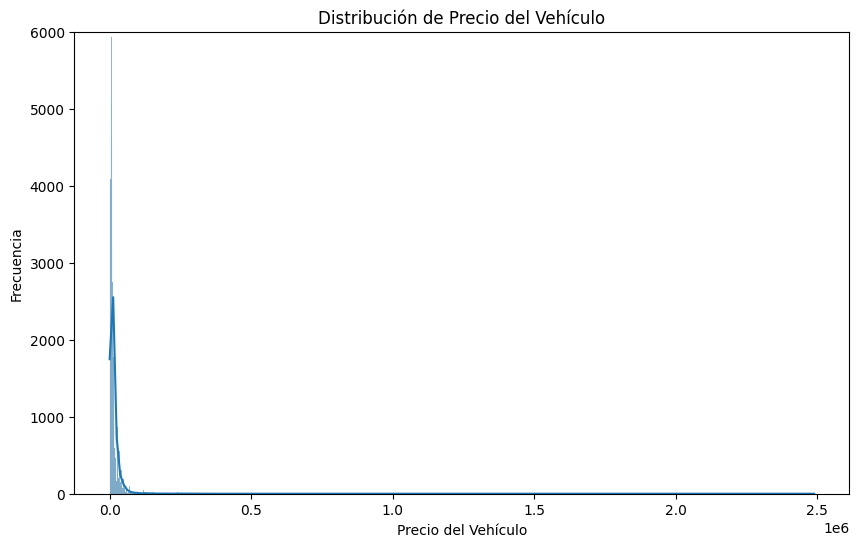

In [148]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train_n['precio_vehiculo'], kde=True)
plt.title('Distribución de Precio del Vehículo')
plt.xlabel('Precio del Vehículo')
plt.ylabel('Frecuencia')
plt.ylim(0, 6000) # Limitamos el eje y a 6000
plt.show()


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='millas_recorridas', data=df_train_n)
plt.title('Bar Chart of Complejidad Reparacion')
plt.xlabel('Complejidad de Reparación')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if needed
plt.show()


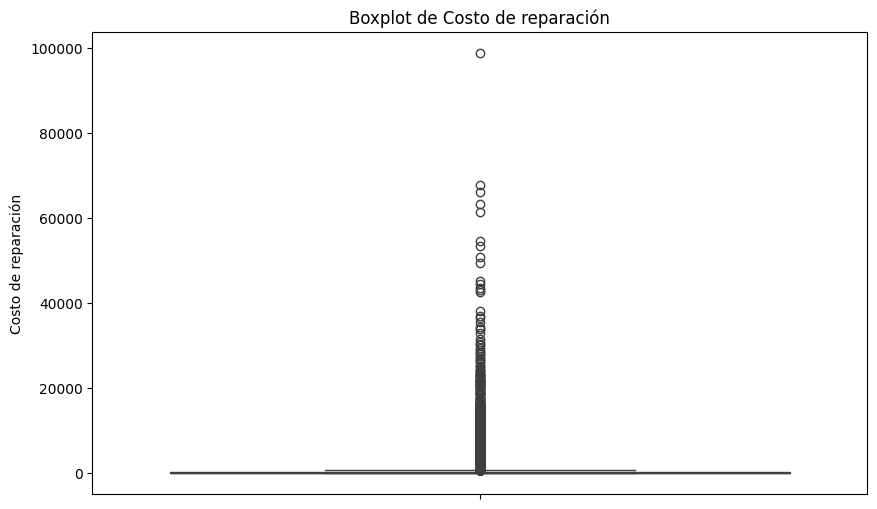

In [148]:
# Assuming df_train_n is your DataFrame
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_train_n['costo_reparacion'])
plt.title('Boxplot de Costo de reparación')
plt.ylabel('Costo de reparación')
plt.show()


Correlación

In [149]:
correlaciones = df_train_n[['fraude','costo_reparacion','precio_vehiculo','millas_recorridas']].corr()
print(correlaciones)

                     fraude  costo_reparacion  precio_vehiculo  \
fraude             1.000000          0.094512         0.075400   
costo_reparacion   0.094512          1.000000         0.299844   
precio_vehiculo    0.075400          0.299844         1.000000   
millas_recorridas -0.020297         -0.126214        -0.308554   

                   millas_recorridas  
fraude                     -0.020297  
costo_reparacion           -0.126214  
precio_vehiculo            -0.308554  
millas_recorridas           1.000000  


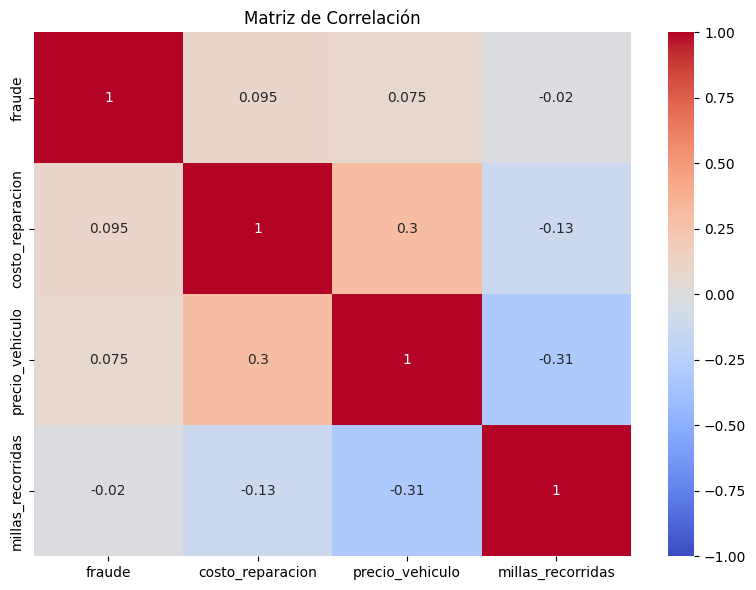

In [150]:
# Visualizar matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('correlaciones.png')
plt.show()

In [151]:
# Calculate skewness and kurtosis
skewness = df_train_n[['precio_vehiculo', 'costo_reparacion', 'millas_recorridas']].skew()
kurtosis = df_train_n[['precio_vehiculo', 'costo_reparacion', 'millas_recorridas']].kurt()

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)


Skewness:
 precio_vehiculo      18.522849
costo_reparacion     21.371247
millas_recorridas     1.237257
dtype: float64

Kurtosis:
 precio_vehiculo      1055.779244
costo_reparacion     1009.528468
millas_recorridas       8.480508
dtype: float64


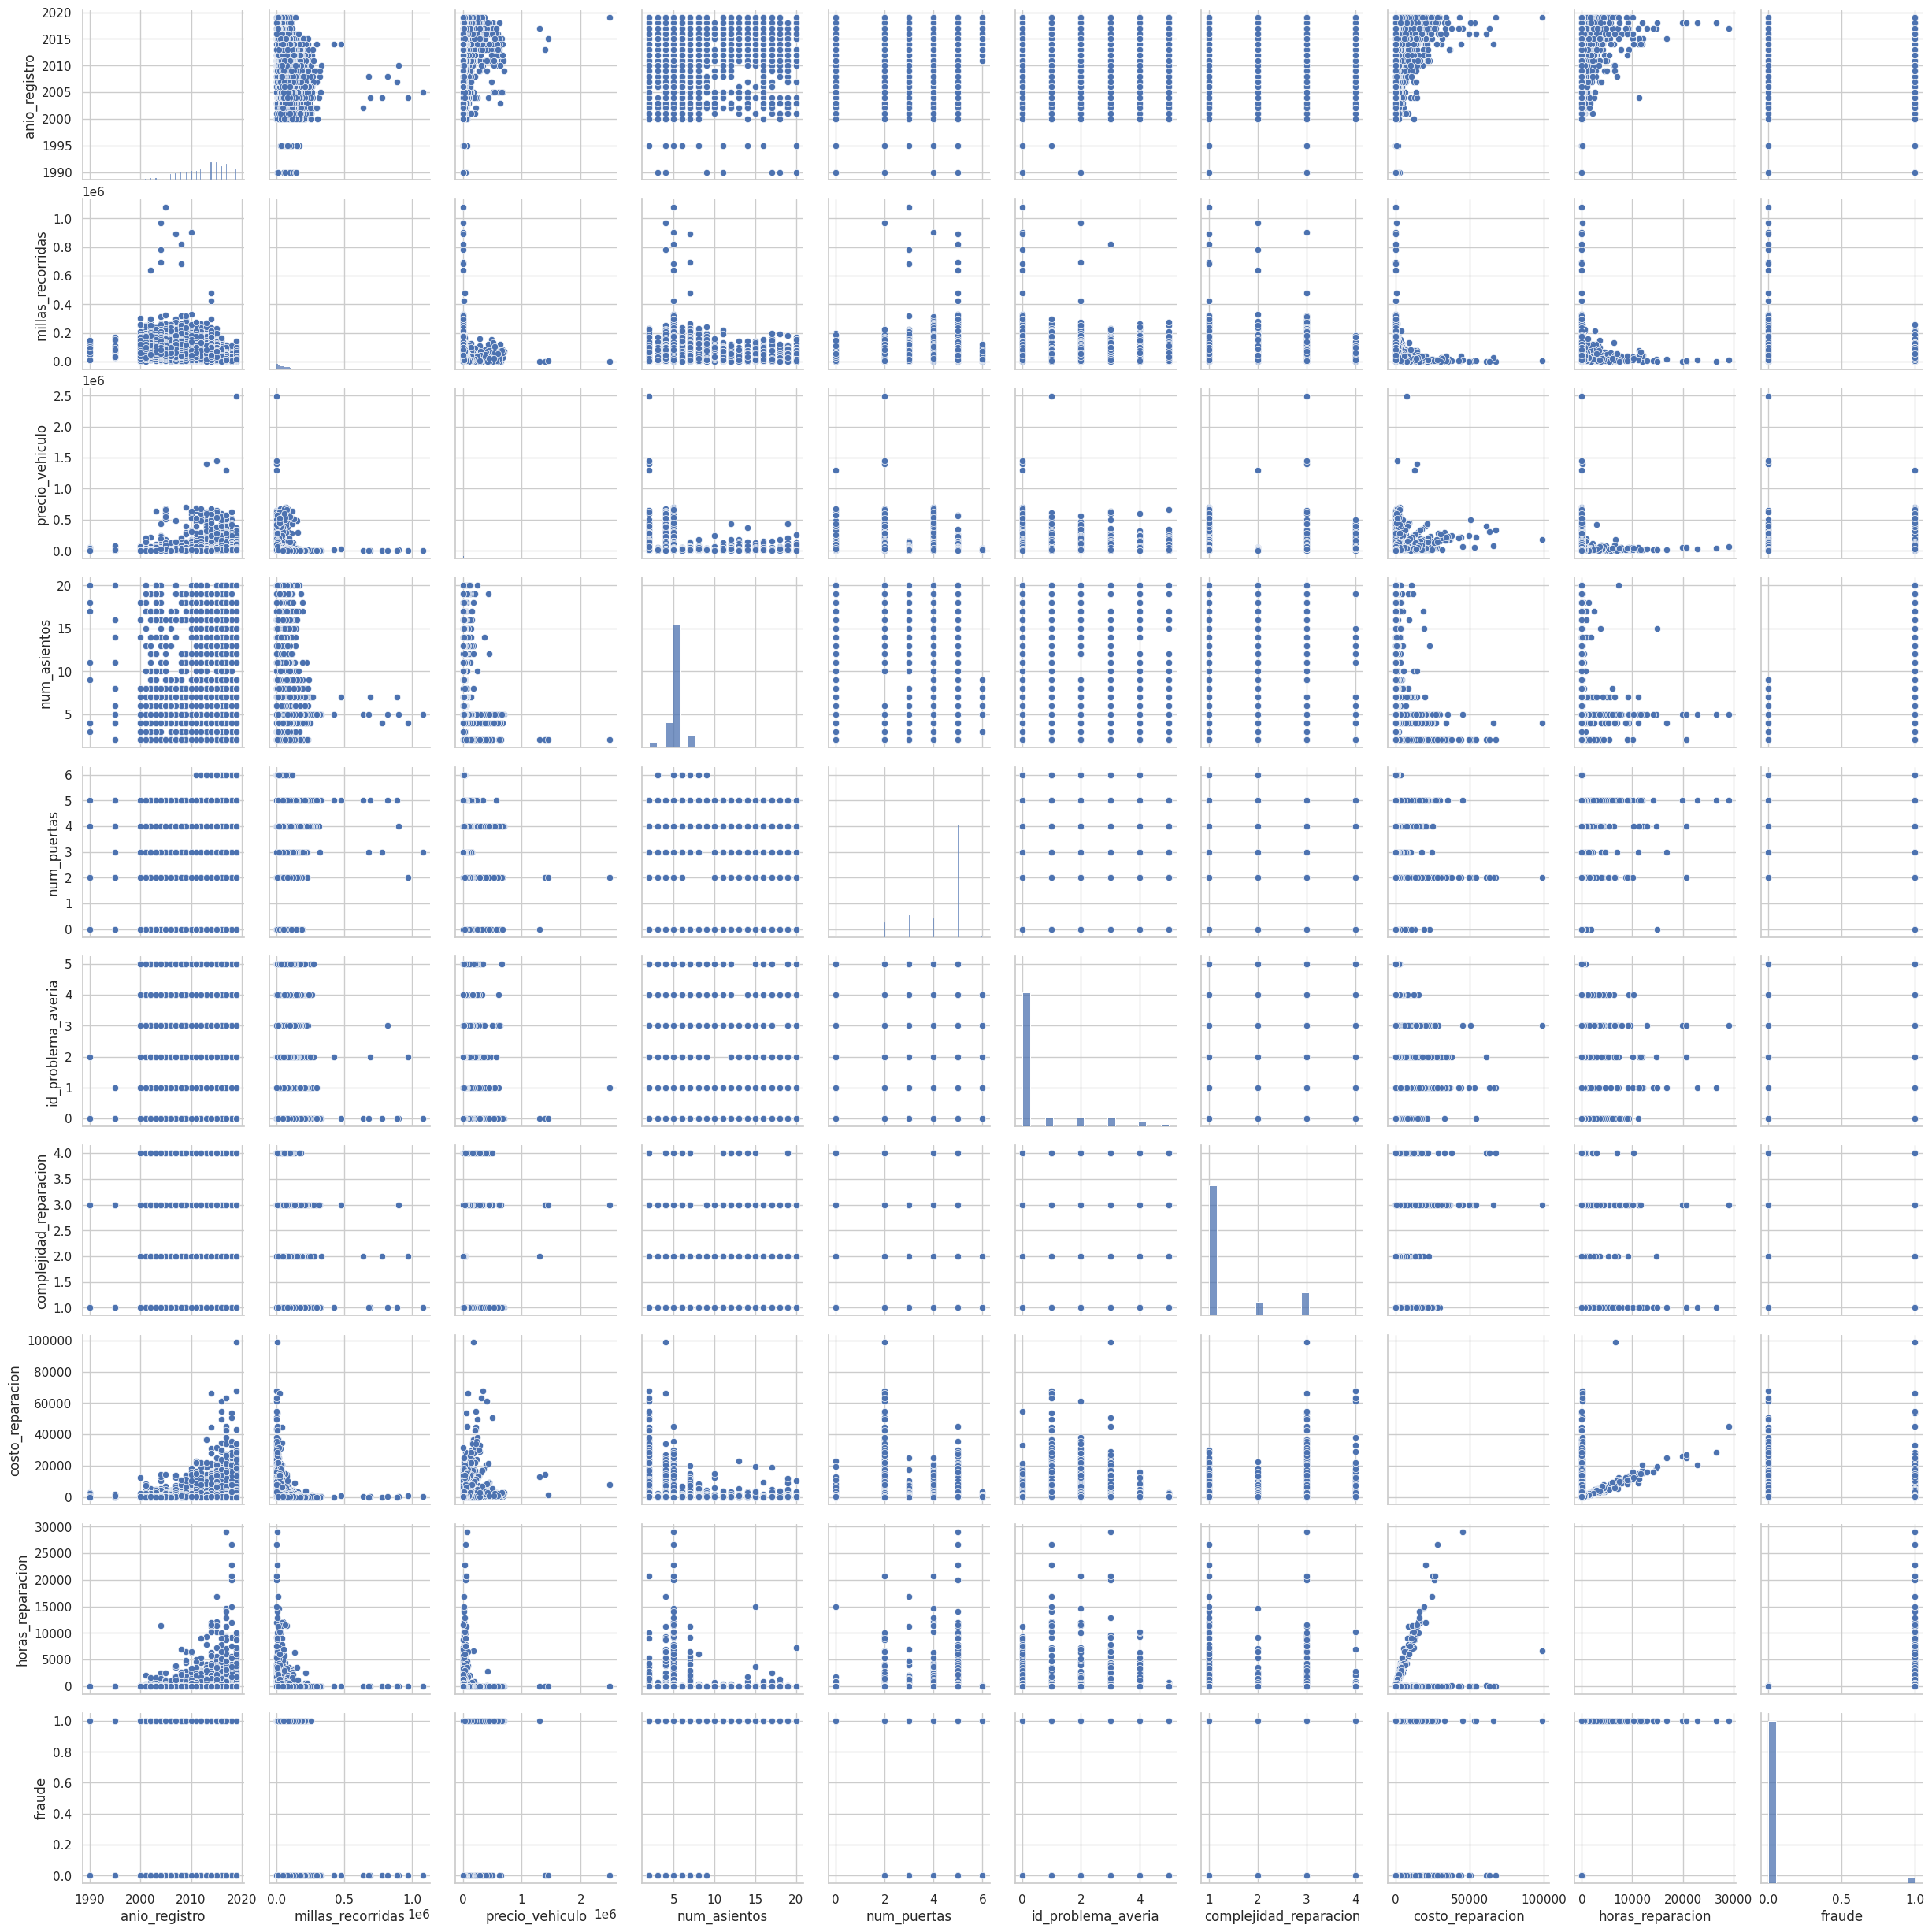

In [161]:
import seaborn as sns
sns.pairplot(df_train_n)

## Análisis Multivariado:
- Elija al menos dos pares de variables (no considere la variable target) y realice un análisis multivariable para cada par.
- Utilice visualizaciones adecuadas (por ejemplo, diagramas de dispersión, gráficos de barras).
- Explique cualquier relación observada entre los pares de variables analizados.


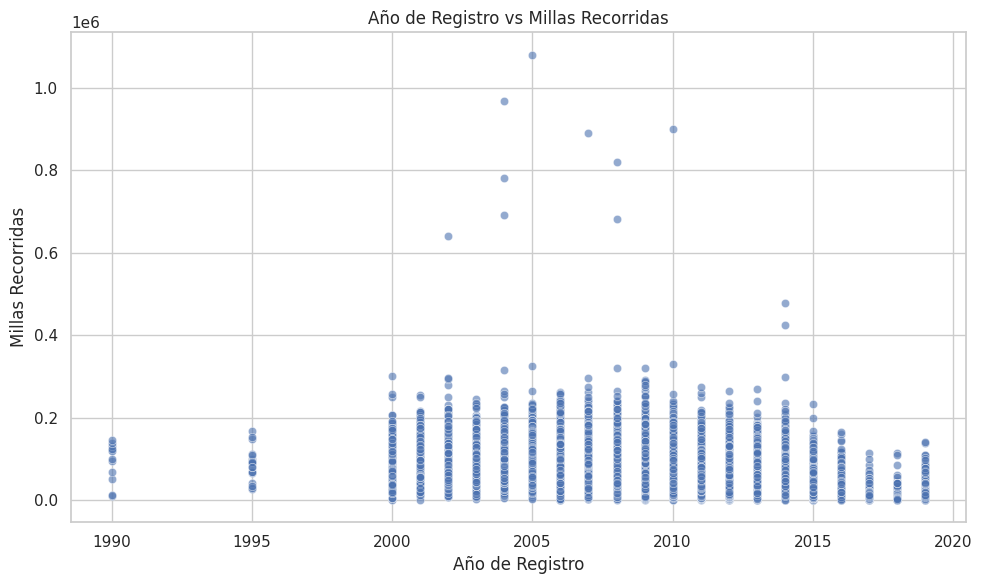

In [153]:
sns.set(style="whitegrid")

# ========== PAR 1: anio_registro vs millas_recorridas ==========
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train_n, x='anio_registro', y='millas_recorridas', alpha=0.6)
plt.title('Año de Registro vs Millas Recorridas')
plt.xlabel('Año de Registro')
plt.ylabel('Millas Recorridas')
plt.tight_layout()
plt.show()

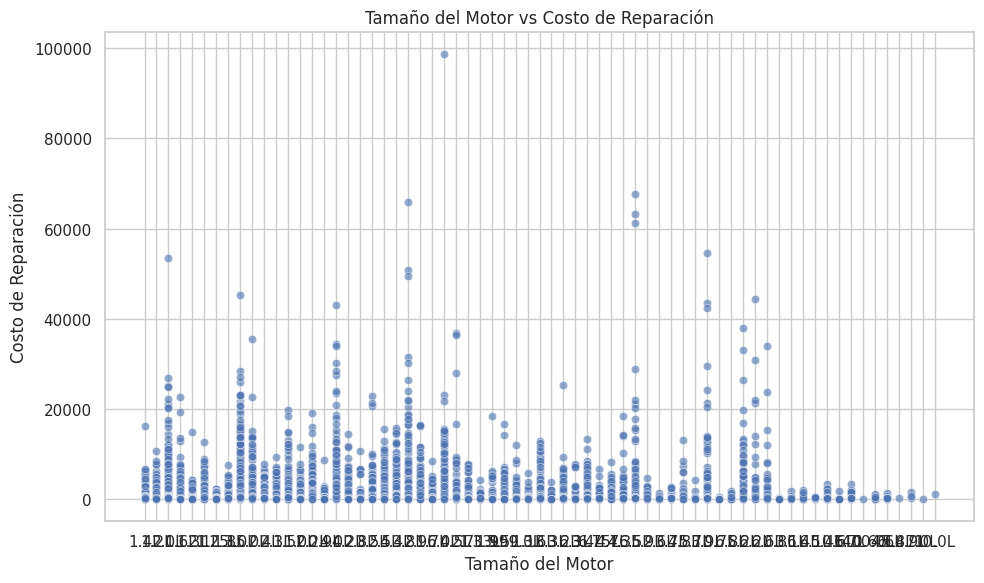

In [157]:
# ========== PAR 2: tamanio_motor vs costo_reparacion ==========
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train_n, x='tamanio_motor', y='costo_reparacion', alpha=0.6)
plt.title('Tamaño del Motor vs Costo de Reparación')
plt.xlabel('Tamaño del Motor')
plt.ylabel('Costo de Reparación')
plt.tight_layout()
plt.show()


- Elija al menos dos variables de variables y realice un análisis multivariable entre las variables elegidas y la variable target.
- Utilice visualizaciones adecuadas (por ejemplo, diagramas de dispersión, gráficos de barras).
- Explique cualquier relación observada entre los pares de variables analizados.


In [169]:
df_train_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   marca                   196429 non-null  object 
 1   modelo                  196429 non-null  object 
 2   color                   196429 non-null  object 
 3   anio_registro           196429 non-null  float64
 4   tipo_vehiculo           196429 non-null  object 
 5   millas_recorridas       196429 non-null  float64
 6   tamanio_motor           196429 non-null  object 
 7   transmision             196429 non-null  object 
 8   tipo_combustible        196429 non-null  object 
 9   precio_vehiculo         196429 non-null  float64
 10  num_asientos            196429 non-null  float64
 11  num_puertas             196429 non-null  float64
 12  problema_averia         196429 non-null  object 
 13  id_problema_averia      196429 non-null  int64  
 14  fecha_averia        

Variables numéricas

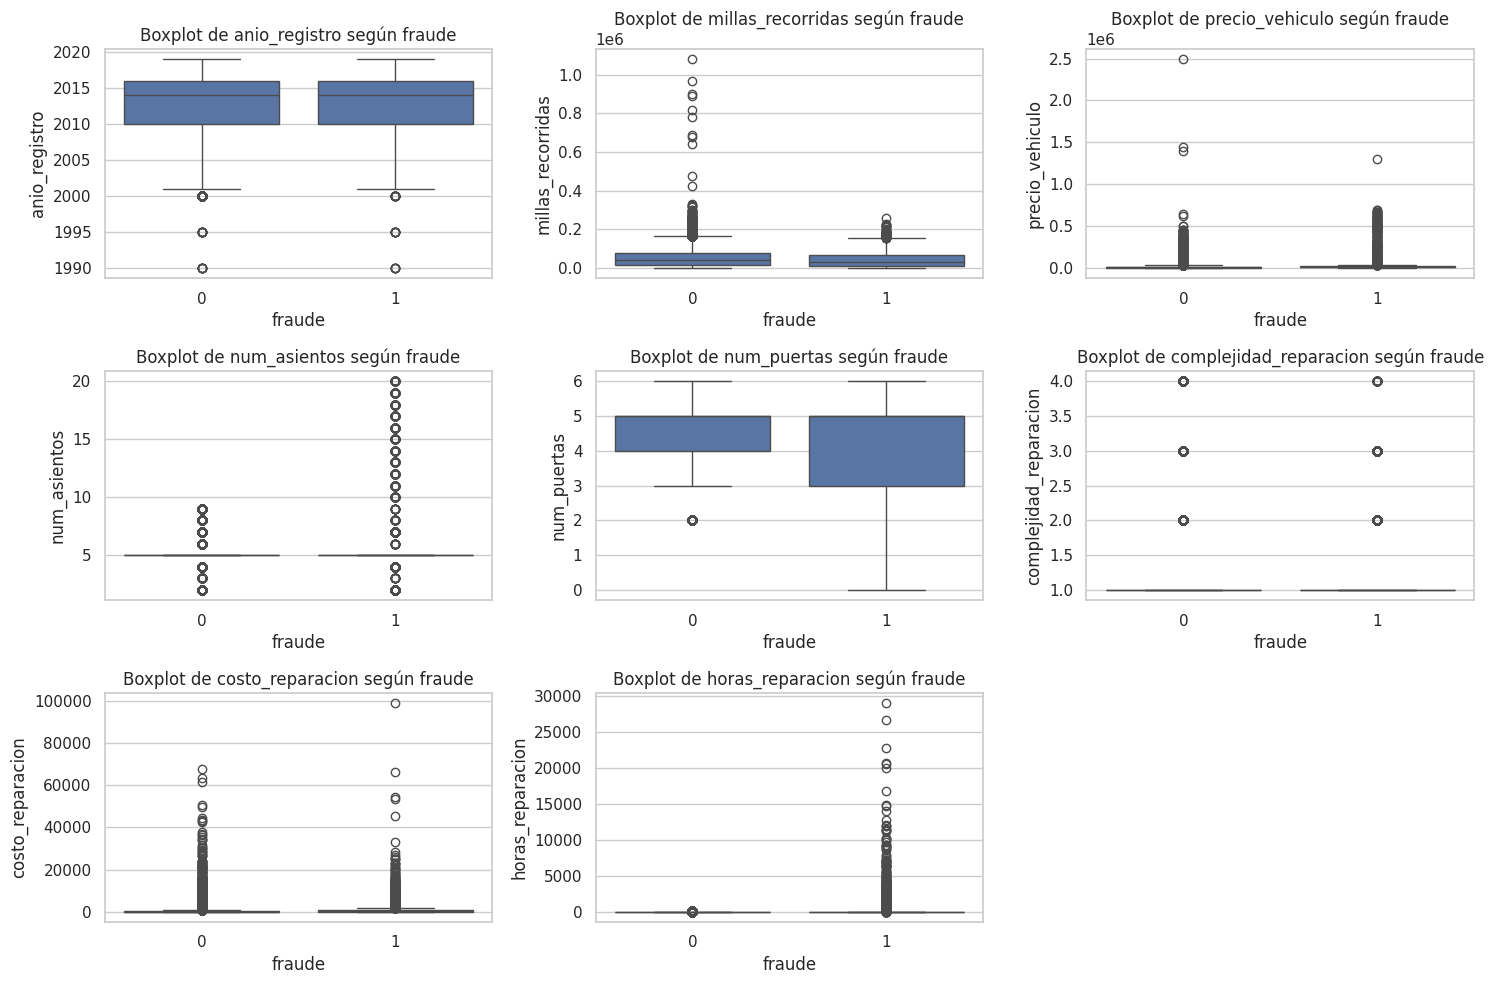

In [173]:
### Variables predictoras según la variable target

###### DIAGRAMAS DE CAJA
import matplotlib.pyplot as plt
import seaborn as sns
import math



df = df_train_n[['anio_registro','millas_recorridas','precio_vehiculo','num_asientos',
    'num_puertas','complejidad_reparacion','costo_reparacion','horas_reparacion','fraude']]

columnas = df.columns[:-1]
plt.figure(figsize=(15, 10))


for i, columna in enumerate(columnas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='fraude',y=df[columna], data=df)
    plt.title(f'Boxplot de {columna} según fraude')


plt.tight_layout()
plt.show()

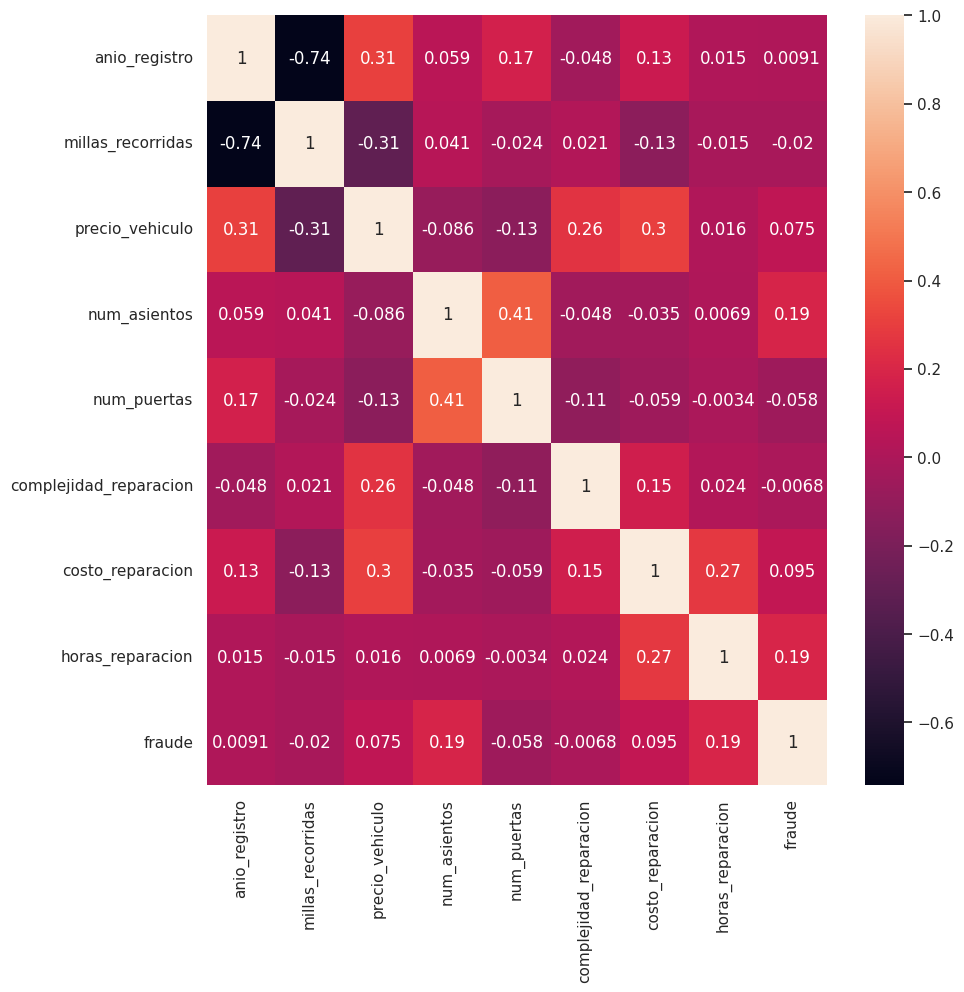

In [179]:
corr_matrix=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True)
plt.show()

Variables categóricas

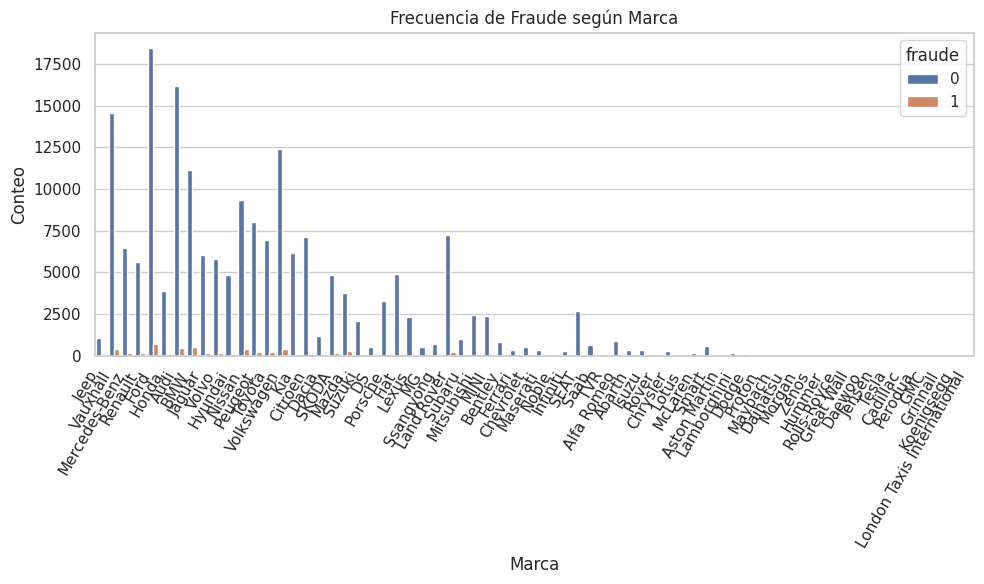

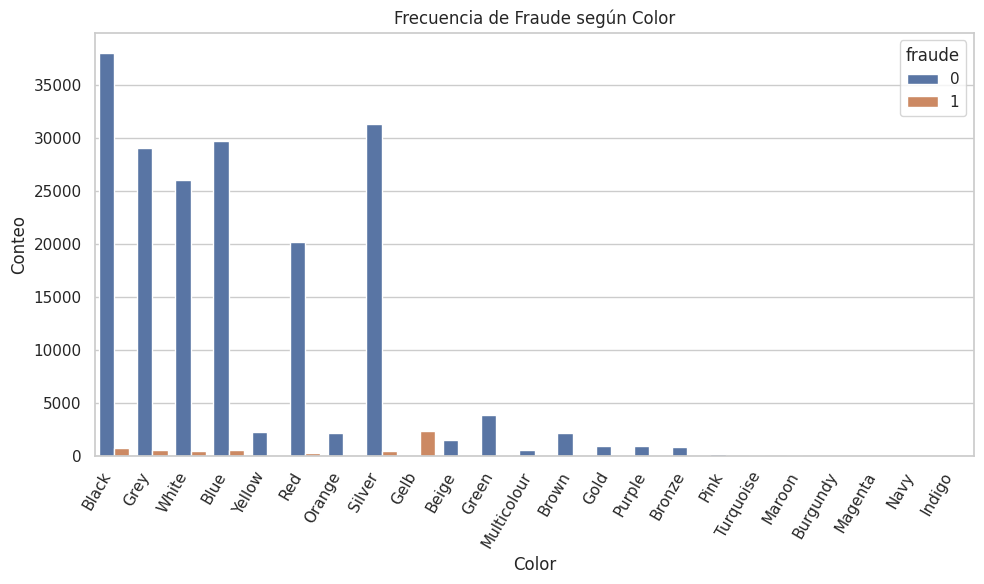

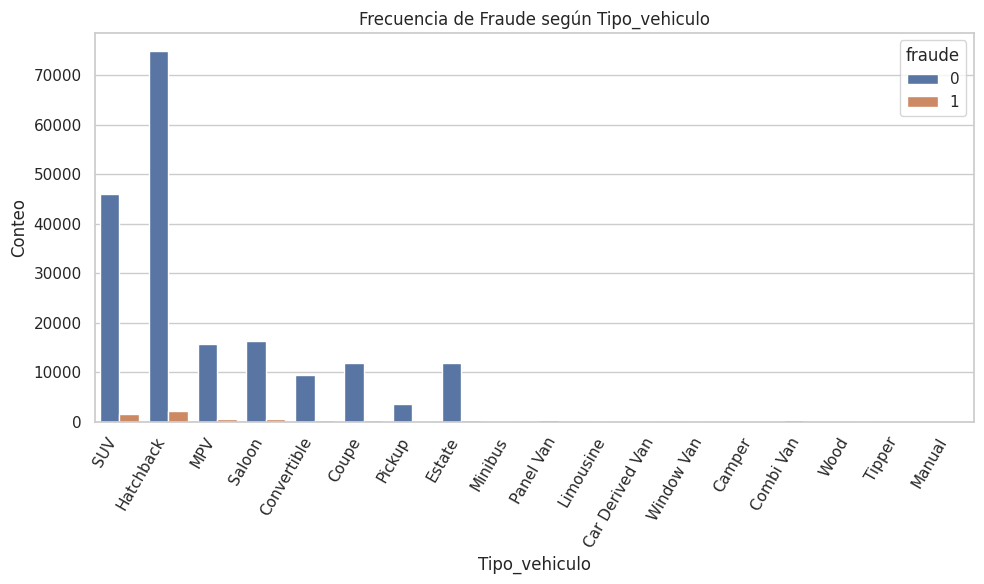

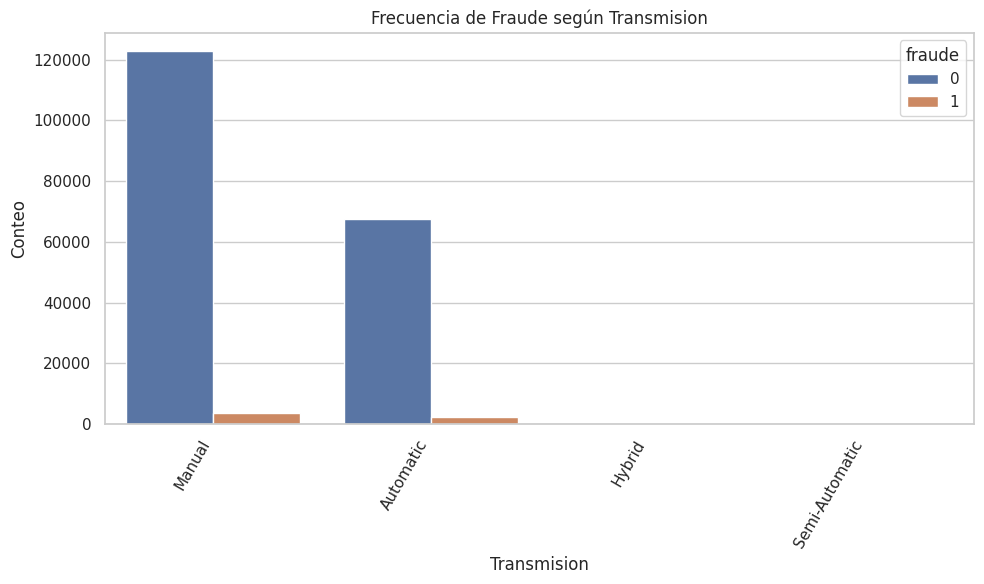

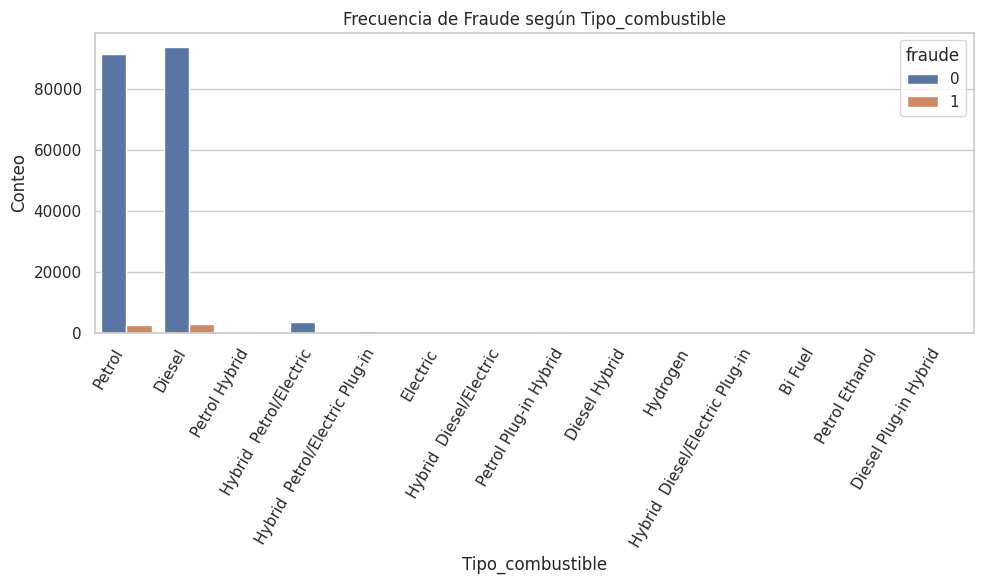

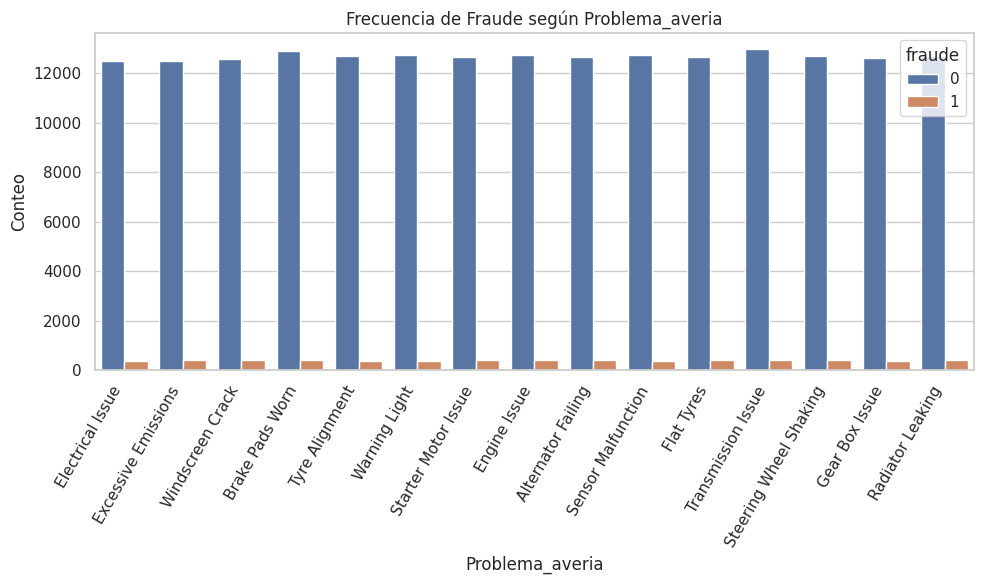

In [177]:
### Variables predictoras según la variable target

###### GRÁFICO DE BARRAS
import matplotlib.pyplot as plt
import seaborn as sns

variables_categoricas = ['marca', 'color', 'tipo_vehiculo','transmision', 'tipo_combustible', 'problema_averia']

# Graficar cada variable categórica vs. 'fraude'
for col in variables_categoricas:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train_n, x=col, hue='fraude')
    plt.title(f'Frecuencia de Fraude según {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Conteo')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()


## Implemente al menos 3 modelos de clasificación e intente superar al baseline compartido.
Para los 3 modelos utilice el mismo algoritmo de clasificación (elija uno aprendido en clases) con diferentes configuraciones. Distintas configuraciones pueden incluir distintos valores de hiperparámetros o técnicas de procesamiento de los datos de entrada. Para las distintas configuraciones puede considerar lo siguiente:
- Sus datos podrían ser estandarizados/normalizados o no.
- Puede definir alguna estrategia para codificar variables categóricas (puede utilizar One-hot-encoding, Target encoding, u otra estrategia).
- Identifique valores faltantes y defina una estrategia (de ser necesario) para la imputación de datos.
- Analice las variables categóricas y determine si es necesario tratar categorías poco frecuentes (por ejemplo, a veces agrupar categorías raras puede ser útil). Explique sus decisiones en el tratamiento de los datos.
- Detecte valores atípicos y defina una estrategia para tratarlos. Considere que eliminar los registros outliers (del set de entrenamiento) no es la única estrategia posible (puede considerar la regla del rango intercuartil, Local Outlier Factor, u otra estrategia). Explique sus decisiones en el tratamiento de los datos.



## Evalúe y compare todos los modelos.
Interprete los resultados y concluya cuál modelo es el mejor. Puede considerar más de una métrica de evaluación para su conclusión.
